# 소주제 1 — 재고 상태 분류 (Multi-class Classification)

> **목표:** 제품의 재고·판매·공급 정보를 기반으로 현재 재고 상태(In Stock / Low Stock / Expiring Soon)를 예측하는 다중 클래스 분류 모델을 구축하고, 상태를 결정짓는 핵심 요인을 도출한다.

---

| 항목 | 내용 |
|------|------|
| **프로젝트** | 머신러닝 기반 식료품 유통 재고 관리 최적화 시스템 |
| **담당** | 정이랑 |
| **데이터** | Inventory Management E-Grocery (1,000행 × 37열) |
| **모델** | Logistic Regression, Random Forest, XGBoost, LightGBM |
| **평가 지표** | Accuracy, Macro F1-Score, Confusion Matrix |

### 도출할 인사이트

1. 재고 상태(Inventory_Status)를 결정짓는 핵심 피처는 무엇인가?
2. Out of Stock이 2건(0.2%)에 불과한 극심한 클래스 불균형 상황에서 어떤 전략이 효과적인가?
3. Confusion Matrix에서 가장 혼동이 많은 클래스 조합은 무엇이며, 그 이유는?
4. Feature Importance 상위 변수가 실무적으로 어떤 의미를 갖는가?
5. ABC 등급(A/B/C)에 따라 재고 상태 분류 패턴이 달라지는가?
6. 데이터 누수(Data Leakage) 피처를 제거했을 때 모델 성능이 어떻게 변하는가?
7. ★ Days_of_Inventory의 간접 누수 가능성은 있는가?
8. ★ Learning Curve를 통한 과적합 수렴 패턴은 어떠한가?
9. ★ Permutation Importance와 Impurity-based Feature Importance의 순위가 일치하는가?

In [1]:
# ========================================
# 0. 라이브러리 임포트 & 설정
# ========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
import warnings
import os
import joblib

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (accuracy_score, f1_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay, make_scorer)
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from collections import Counter

# 한글 폰트 설정 — Malgun Gothic (matplotlib 내장 폰트 디렉토리에 복사됨)
# 캐시 강제 재빌드하여 새 폰트 인식
fm._load_fontmanager(try_read_cache=False)
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 150
sns.set_style('whitegrid')
sns.set_palette('Set2')
# whitegrid 적용 후 font.family가 리셋되지 않도록 재설정
plt.rcParams['font.family'] = 'Malgun Gothic'

# 경고 숨김 & 시드 고정
warnings.filterwarnings('ignore')
SEED = 42
np.random.seed(SEED)

# 출력 디렉토리 설정
BASE_DIR = os.path.dirname(os.path.abspath('__file__'))
FIG_DIR = os.path.join(BASE_DIR, '..', 'outputs', 'figures')
MODEL_DIR = os.path.join(BASE_DIR, '..', 'outputs', 'models')
os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(MODEL_DIR, exist_ok=True)

print('✅ 라이브러리 및 설정 완료')
print(f'   한글 폰트: {plt.rcParams["font.family"]}')
# 폰트 검증
_test_font = fm.findfont('Malgun Gothic')
print(f'   폰트 경로: {_test_font}')
print(f'   저장 경로 (figures): {os.path.abspath(FIG_DIR)}')
print(f'   저장 경로 (models) : {os.path.abspath(MODEL_DIR)}')

Matplotlib is building the font cache; this may take a moment.


✅ 라이브러리 및 설정 완료
   한글 폰트: ['Malgun Gothic']
   폰트 경로: /opt/anaconda3/lib/python3.13/site-packages/matplotlib/mpl-data/fonts/ttf/malgun.ttf
   저장 경로 (figures): /Volumes/Corsair EX300U Media/00_work_out/02_ing/Phase8_mini/outputs/figures
   저장 경로 (models) : /Volumes/Corsair EX300U Media/00_work_out/02_ing/Phase8_mini/outputs/models


---

## 1. 데이터 로드 & 기본 확인

원본 데이터: **Inventory Management E-Grocery** (인도네시아 E-Grocery 업체 재고 관리 데이터)
- 규모: 1,000행 × 37열
- 특성: 인도네시아 로케일 형식 (쉼표 소수점, `$` 금액 형식 등)

In [2]:
# ========================================
# 1. 데이터 로드 & 기본 확인
# ========================================
DATA_PATH = os.path.join(
    BASE_DIR, '..', 'data',
    'Supply Chain Inventory Management Grocery Industry',
    'Inventory Management E-Grocery - InventoryData.csv'
)
df_raw = pd.read_csv(DATA_PATH)

print(f'📊 데이터 형태: {df_raw.shape[0]:,}행 × {df_raw.shape[1]}열')
print(f'\n📋 컬럼 목록 ({df_raw.shape[1]}개):')
for i, col in enumerate(df_raw.columns, 1):
    print(f'   {i:2d}. {col} ({df_raw[col].dtype})')

📊 데이터 형태: 1,000행 × 37열

📋 컬럼 목록 (37개):
    1. SKU_ID (object)
    2. SKU_Name (object)
    3. Category (object)
    4. ABC_Class (object)
    5. Supplier_ID (object)
    6. Supplier_Name (object)
    7. Warehouse_ID (object)
    8. Warehouse_Location (object)
    9. Batch_ID (object)
   10. Received_Date (object)
   11. Last_Purchase_Date (object)
   12. Expiry_Date (object)
   13. Stock_Age_Days (int64)
   14. Quantity_On_Hand (int64)
   15. Quantity_Reserved (int64)
   16. Quantity_Committed (int64)
   17. Damaged_Qty (int64)
   18. Returns_Qty (int64)
   19. Avg_Daily_Sales (object)
   20. Forecast_Next_30d (float64)
   21. Days_of_Inventory (object)
   22. Reorder_Point (float64)
   23. Safety_Stock (int64)
   24. Lead_Time_Days (int64)
   25. Unit_Cost_USD (object)
   26. Last_Purchase_Price_USD (object)
   27. Total_Inventory_Value_USD (object)
   28. SKU_Churn_Rate (object)
   29. Order_Frequency_per_month (object)
   30. Supplier_OnTime_Pct (object)
   31. FIFO_FEFO (object)
  

In [3]:
# 기본 통계 확인
print('=' * 60)
print('기본 정보 (df.info)')
print('=' * 60)
df_raw.info()

기본 정보 (df.info)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 37 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   SKU_ID                        1000 non-null   object 
 1   SKU_Name                      1000 non-null   object 
 2   Category                      1000 non-null   object 
 3   ABC_Class                     1000 non-null   object 
 4   Supplier_ID                   1000 non-null   object 
 5   Supplier_Name                 1000 non-null   object 
 6   Warehouse_ID                  1000 non-null   object 
 7   Warehouse_Location            1000 non-null   object 
 8   Batch_ID                      1000 non-null   object 
 9   Received_Date                 1000 non-null   object 
 10  Last_Purchase_Date            1000 non-null   object 
 11  Expiry_Date                   1000 non-null   object 
 12  Stock_Age_Days                1000 non-null   i

In [4]:
# 결측치 확인
print('\n📌 결측치 현황:')
missing = df_raw.isnull().sum()
missing_cols = missing[missing > 0]
if len(missing_cols) == 0:
    print('   → 결측치 없음')
else:
    for col, cnt in missing_cols.items():
        print(f'   {col}: {cnt}건 ({cnt/len(df_raw)*100:.1f}%)')
print()

# 타겟 변수 분포
print('🎯 타겟 변수 — Inventory_Status 분포:')
status_counts = df_raw['Inventory_Status'].value_counts()
for status, cnt in status_counts.items():
    print(f'   {status:15s}: {cnt:4d}건 ({cnt/len(df_raw)*100:.1f}%)')

print()
print('📦 ABC_Class 분포:')
abc_counts = df_raw['ABC_Class'].value_counts().sort_index()
for cls, cnt in abc_counts.items():
    print(f'   {cls}: {cnt:4d}건 ({cnt/len(df_raw)*100:.1f}%)')


📌 결측치 현황:
   Notes: 834건 (83.4%)

🎯 타겟 변수 — Inventory_Status 분포:
   In Stock       :  428건 (42.8%)
   Expiring Soon  :  329건 (32.9%)
   Low Stock      :  241건 (24.1%)
   Out of Stock   :    2건 (0.2%)

📦 ABC_Class 분포:
   A:  200건 (20.0%)
   B:  300건 (30.0%)
   C:  500건 (50.0%)


---

## 2. 데이터 전처리

### 2.1 공통 전처리 — 인도네시아 로케일 변환

원본 데이터의 숫자 형식이 인도네시아 로케일을 따르므로 다음 변환을 수행한다:

| 형식 | 해당 컬럼 | 변환 규칙 |
|------|-----------|-----------|
| 쉼표 소수점 (`"45,23"`, `"2.142,90"`) | Avg_Daily_Sales, Days_of_Inventory 등 | `.`(천단위) 제거 → `,` → `.` → float |
| 마침표 천단위 정수 (`"1.377"`, `"1.170"`) | Forecast_Next_30d, **Reorder_Point** | raw 문자열 재로드 → `.` 제거 → int |
| 금액 (`"$2.084,25"`) | Unit_Cost_USD 등 | `$` 제거 → `.`(천단위) 제거 → `,` → `.` → float |
| 퍼센트 (`"85,5%"`) | Supplier_OnTime_Pct 등 | `%` 제거 → `,` → `.` → float |

> ⚠️ **주의:** `Forecast_Next_30d`(276건)와 `Reorder_Point`(10건)는 pandas가 마침표를 소수점으로 잘못 파싱하여 값이 1/1000로 축소됨. `dtype=str`로 재로드하여 수정 필수.

In [5]:
# ========================================
# 2. 데이터 전처리
# ========================================
df = df_raw.copy()

# 2-1. 인도네시아 로케일 숫자 변환
comma_decimal_cols = [
    'Avg_Daily_Sales', 'Days_of_Inventory',
    'SKU_Churn_Rate', 'Order_Frequency_per_month'
]
for col in comma_decimal_cols:
    df[col] = (df[col].astype(str)
               .str.replace('.', '', regex=False)
               .str.replace(',', '.', regex=False)
               .astype(float))
print('✅ 쉼표 소수점 변환 완료:', comma_decimal_cols)

# 2-1b. 마침표 천단위 정수 컬럼 — 치명적 오파싱 수정
dot_thousand_cols = ['Forecast_Next_30d', 'Reorder_Point']
df_raw_str = pd.read_csv(DATA_PATH, usecols=dot_thousand_cols, dtype=str)
for col in dot_thousand_cols:
    raw_series = df_raw_str[col].str.replace('.', '', regex=False).astype(int)
    n_changed = (df[col].astype(int) != raw_series).sum()
    df[col] = raw_series
    print(f'✅ {col} 변환 완료 (range: {df[col].min()} ~ {df[col].max()})')

# 2-2. 금액 컬럼
money_cols = ['Unit_Cost_USD', 'Last_Purchase_Price_USD', 'Total_Inventory_Value_USD']
for col in money_cols:
    df[col] = (df[col].astype(str)
               .str.replace('$', '', regex=False)
               .str.replace('.', '', regex=False)
               .str.replace(',', '.', regex=False)
               .astype(float))
print('✅ 금액 컬럼 변환 완료:', money_cols)

# 2-3. 퍼센트 컬럼
pct_cols = ['Supplier_OnTime_Pct', 'Audit_Variance_Pct', 'Demand_Forecast_Accuracy_Pct']
for col in pct_cols:
    df[col] = (df[col].astype(str)
               .str.replace('%', '', regex=False)
               .str.replace(',', '.', regex=False)
               .astype(float))
print('✅ 퍼센트 컬럼 변환 완료:', pct_cols)

# 2-4. 날짜 컬럼
date_cols = ['Received_Date', 'Last_Purchase_Date', 'Expiry_Date', 'Audit_Date']
for col in date_cols:
    df[col] = pd.to_datetime(df[col])
print('✅ 날짜 컬럼 파싱 완료:', date_cols)

print('\n📊 변환 후 주요 수치형 컬럼 통계:')
display(df[['Quantity_On_Hand', 'Reorder_Point', 'Safety_Stock', 'Unit_Cost_USD',
            'Avg_Daily_Sales', 'Days_of_Inventory']].describe().round(2))

✅ 쉼표 소수점 변환 완료: ['Avg_Daily_Sales', 'Days_of_Inventory', 'SKU_Churn_Rate', 'Order_Frequency_per_month']
✅ Forecast_Next_30d 변환 완료 (range: 25 ~ 3833)
✅ Reorder_Point 변환 완료 (range: 3 ~ 1870)
✅ 금액 컬럼 변환 완료: ['Unit_Cost_USD', 'Last_Purchase_Price_USD', 'Total_Inventory_Value_USD']
✅ 퍼센트 컬럼 변환 완료: ['Supplier_OnTime_Pct', 'Audit_Variance_Pct', 'Demand_Forecast_Accuracy_Pct']
✅ 날짜 컬럼 파싱 완료: ['Received_Date', 'Last_Purchase_Date', 'Expiry_Date', 'Audit_Date']

📊 변환 후 주요 수치형 컬럼 통계:


,Quantity_On_Hand,Reorder_Point,Safety_Stock,Unit_Cost_USD,Avg_Daily_Sales,Days_of_Inventory
count,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00
mean,231.56,165.42,58.47,6.39,26.58,9.99
std,201.99,197.98,66.05,5.39,21.25,3.80
min,0.00,3.00,2.00,0.29,1.01,0.00
25%,81.00,48.00,19.00,2.15,10.73,7.42
50%,180.00,100.00,36.50,4.66,20.23,9.98
75%,320.00,203.00,70.25,8.86,36.58,12.48
max,977.00,1870.00,624.00,24.90,99.50,21.95


### 2.2 파생변수 생성

| 파생 변수 | 생성 방식 | 의미 |
|-----------|-----------|------|
| Days_To_Expiry | Expiry_Date − Received_Date | 총 유통기한 일수 |
| Days_Since_Last_Order | Received_Date − Last_Purchase_Date | 최근 발주 후 경과 일수 |
| Stock_Gap | Reorder_Point − Quantity_On_Hand | 양수 = 재고 부족 |
| Available_Stock | QoH − Reserved − Committed | 실 가용 재고 |

In [6]:
# 2.5 파생변수 생성
df['Days_To_Expiry'] = (df['Expiry_Date'] - df['Received_Date']).dt.days
df['Days_Since_Last_Order'] = (df['Received_Date'] - df['Last_Purchase_Date']).dt.days
df['Stock_Gap'] = df['Reorder_Point'] - df['Quantity_On_Hand']
df['Available_Stock'] = df['Quantity_On_Hand'] - df['Quantity_Reserved'] - df['Quantity_Committed']

print('✅ 파생변수 4개 생성 완료')
for feat in ['Days_To_Expiry', 'Days_Since_Last_Order', 'Stock_Gap', 'Available_Stock']:
    print(f'   {feat:25s}: min={df[feat].min():8.1f}, max={df[feat].max():8.1f}, mean={df[feat].mean():8.1f}')

✅ 파생변수 4개 생성 완료
   Days_To_Expiry           : min=     2.0, max=  1824.0, mean=   570.4
   Days_Since_Last_Order    : min=     0.0, max=    60.0, mean=    29.4
   Stock_Gap                : min=  -876.0, max=  1869.0, mean=   -66.1
   Available_Stock          : min=  -672.0, max=   747.0, mean=   142.5


### 2.3 타겟 변수 재구성 — Out of Stock → Low Stock 병합 (3클래스)

| 원본 (4클래스) | 건수 | 변환 후 (3클래스) | 건수 |
|---------------|------|------------------|------|
| In Stock | 428 | In Stock | 428 |
| Expiring Soon | 329 | Expiring Soon | 329 |
| Low Stock | 241 | Low Stock | **243** |
| Out of Stock | 2 | *(Low Stock에 병합)* | |

> Out of Stock(2건, 0.2%)은 극심한 클래스 불균형으로 독립 학습이 불가능하여 Low Stock에 병합한다.

In [7]:
# 3클래스 타겟 생성
status_map = {
    'In Stock': 'In Stock',
    'Expiring Soon': 'Expiring Soon',
    'Low Stock': 'Low Stock',
    'Out of Stock': 'Low Stock'
}
df['Status_3cls'] = df['Inventory_Status'].map(status_map)

print('📊 3클래스 버전 — Status_3cls 분포:')
for status, cnt in df['Status_3cls'].value_counts().items():
    print(f'   {status:15s}: {cnt:4d}건 ({cnt/len(df)*100:.1f}%)')

print(f'\n📊 4클래스 원본 — Inventory_Status 분포:')
for status, cnt in df['Inventory_Status'].value_counts().items():
    print(f'   {status:15s}: {cnt:4d}건 ({cnt/len(df)*100:.1f}%)')

📊 3클래스 버전 — Status_3cls 분포:
   In Stock       :  428건 (42.8%)
   Expiring Soon  :  329건 (32.9%)
   Low Stock      :  243건 (24.3%)

📊 4클래스 원본 — Inventory_Status 분포:
   In Stock       :  428건 (42.8%)
   Expiring Soon  :  329건 (32.9%)
   Low Stock      :  241건 (24.1%)
   Out of Stock   :    2건 (0.2%)


---

## 3. 탐색적 데이터 분석 (EDA)

### 3.1 타겟 변수 분포

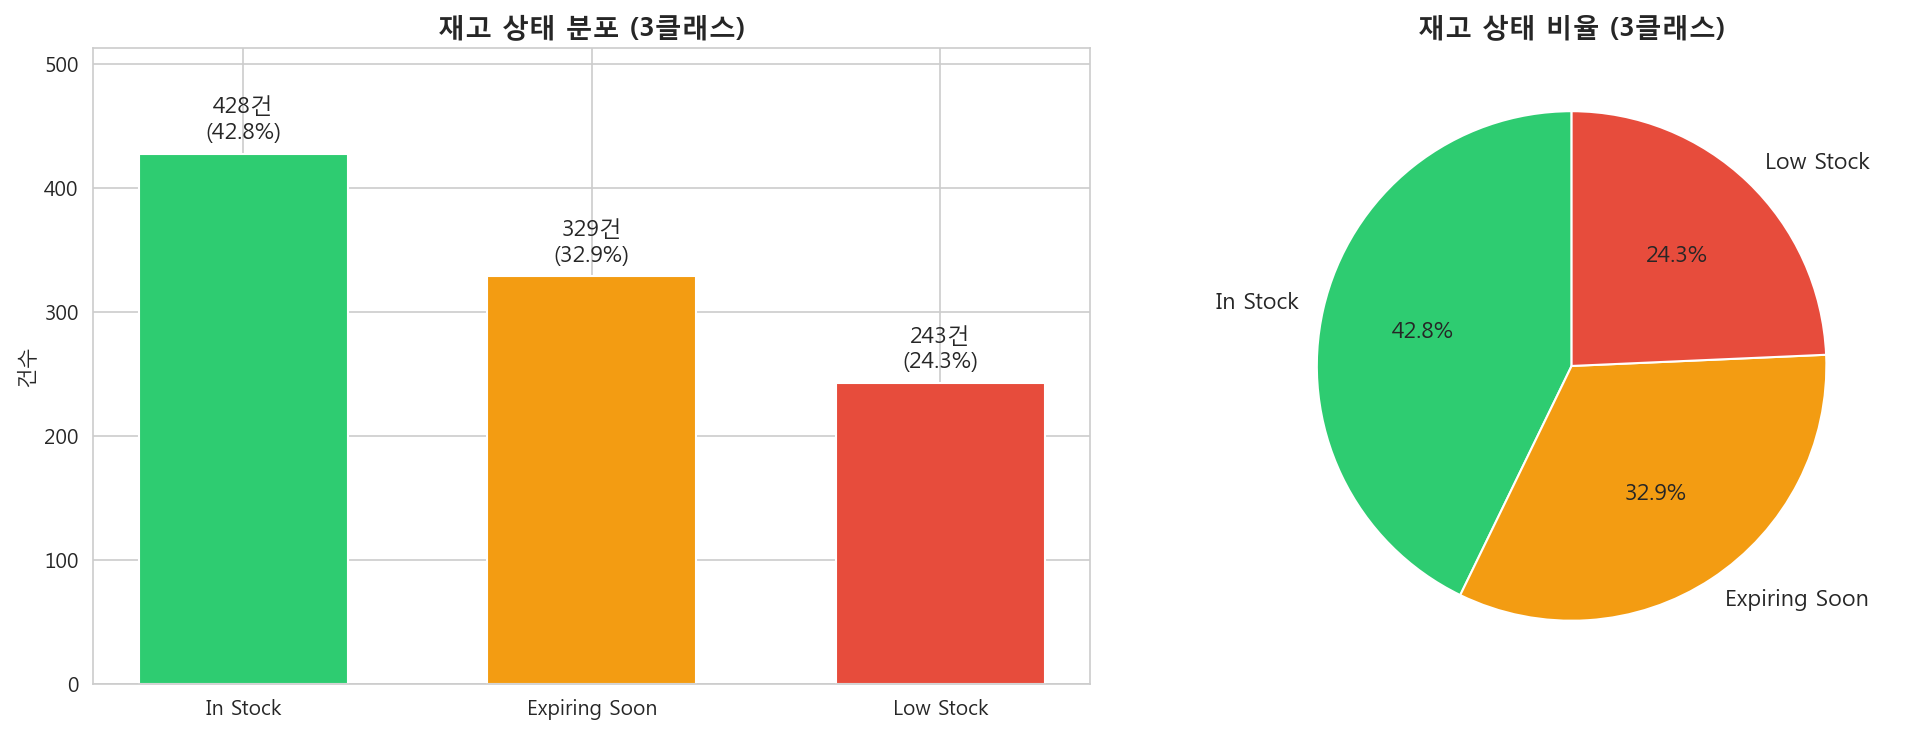

✅ 저장: eda_status_distribution.png


In [8]:
# 3.1 타겟 변수 분포
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

order_3 = ['In Stock', 'Expiring Soon', 'Low Stock']
colors_3 = ['#2ecc71', '#f39c12', '#e74c3c']

ax = axes[0]
counts = df['Status_3cls'].value_counts().reindex(order_3)
bars = ax.bar(counts.index, counts.values, color=colors_3, edgecolor='white', width=0.6)
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 8,
            f'{val}건\n({val/len(df)*100:.1f}%)', ha='center', va='bottom', fontsize=11)
ax.set_title('재고 상태 분포 (3클래스)', fontsize=13, fontweight='bold')
ax.set_ylabel('건수')
ax.set_ylim(0, counts.max() * 1.2)

ax = axes[1]
ax.pie(counts.values, labels=counts.index, colors=colors_3, autopct='%1.1f%%',
       startangle=90, textprops={'fontsize': 11})
ax.set_title('재고 상태 비율 (3클래스)', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'eda_status_distribution.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print('✅ 저장: eda_status_distribution.png')

### 3.2 주요 수치형 피처 분포 (Status별)

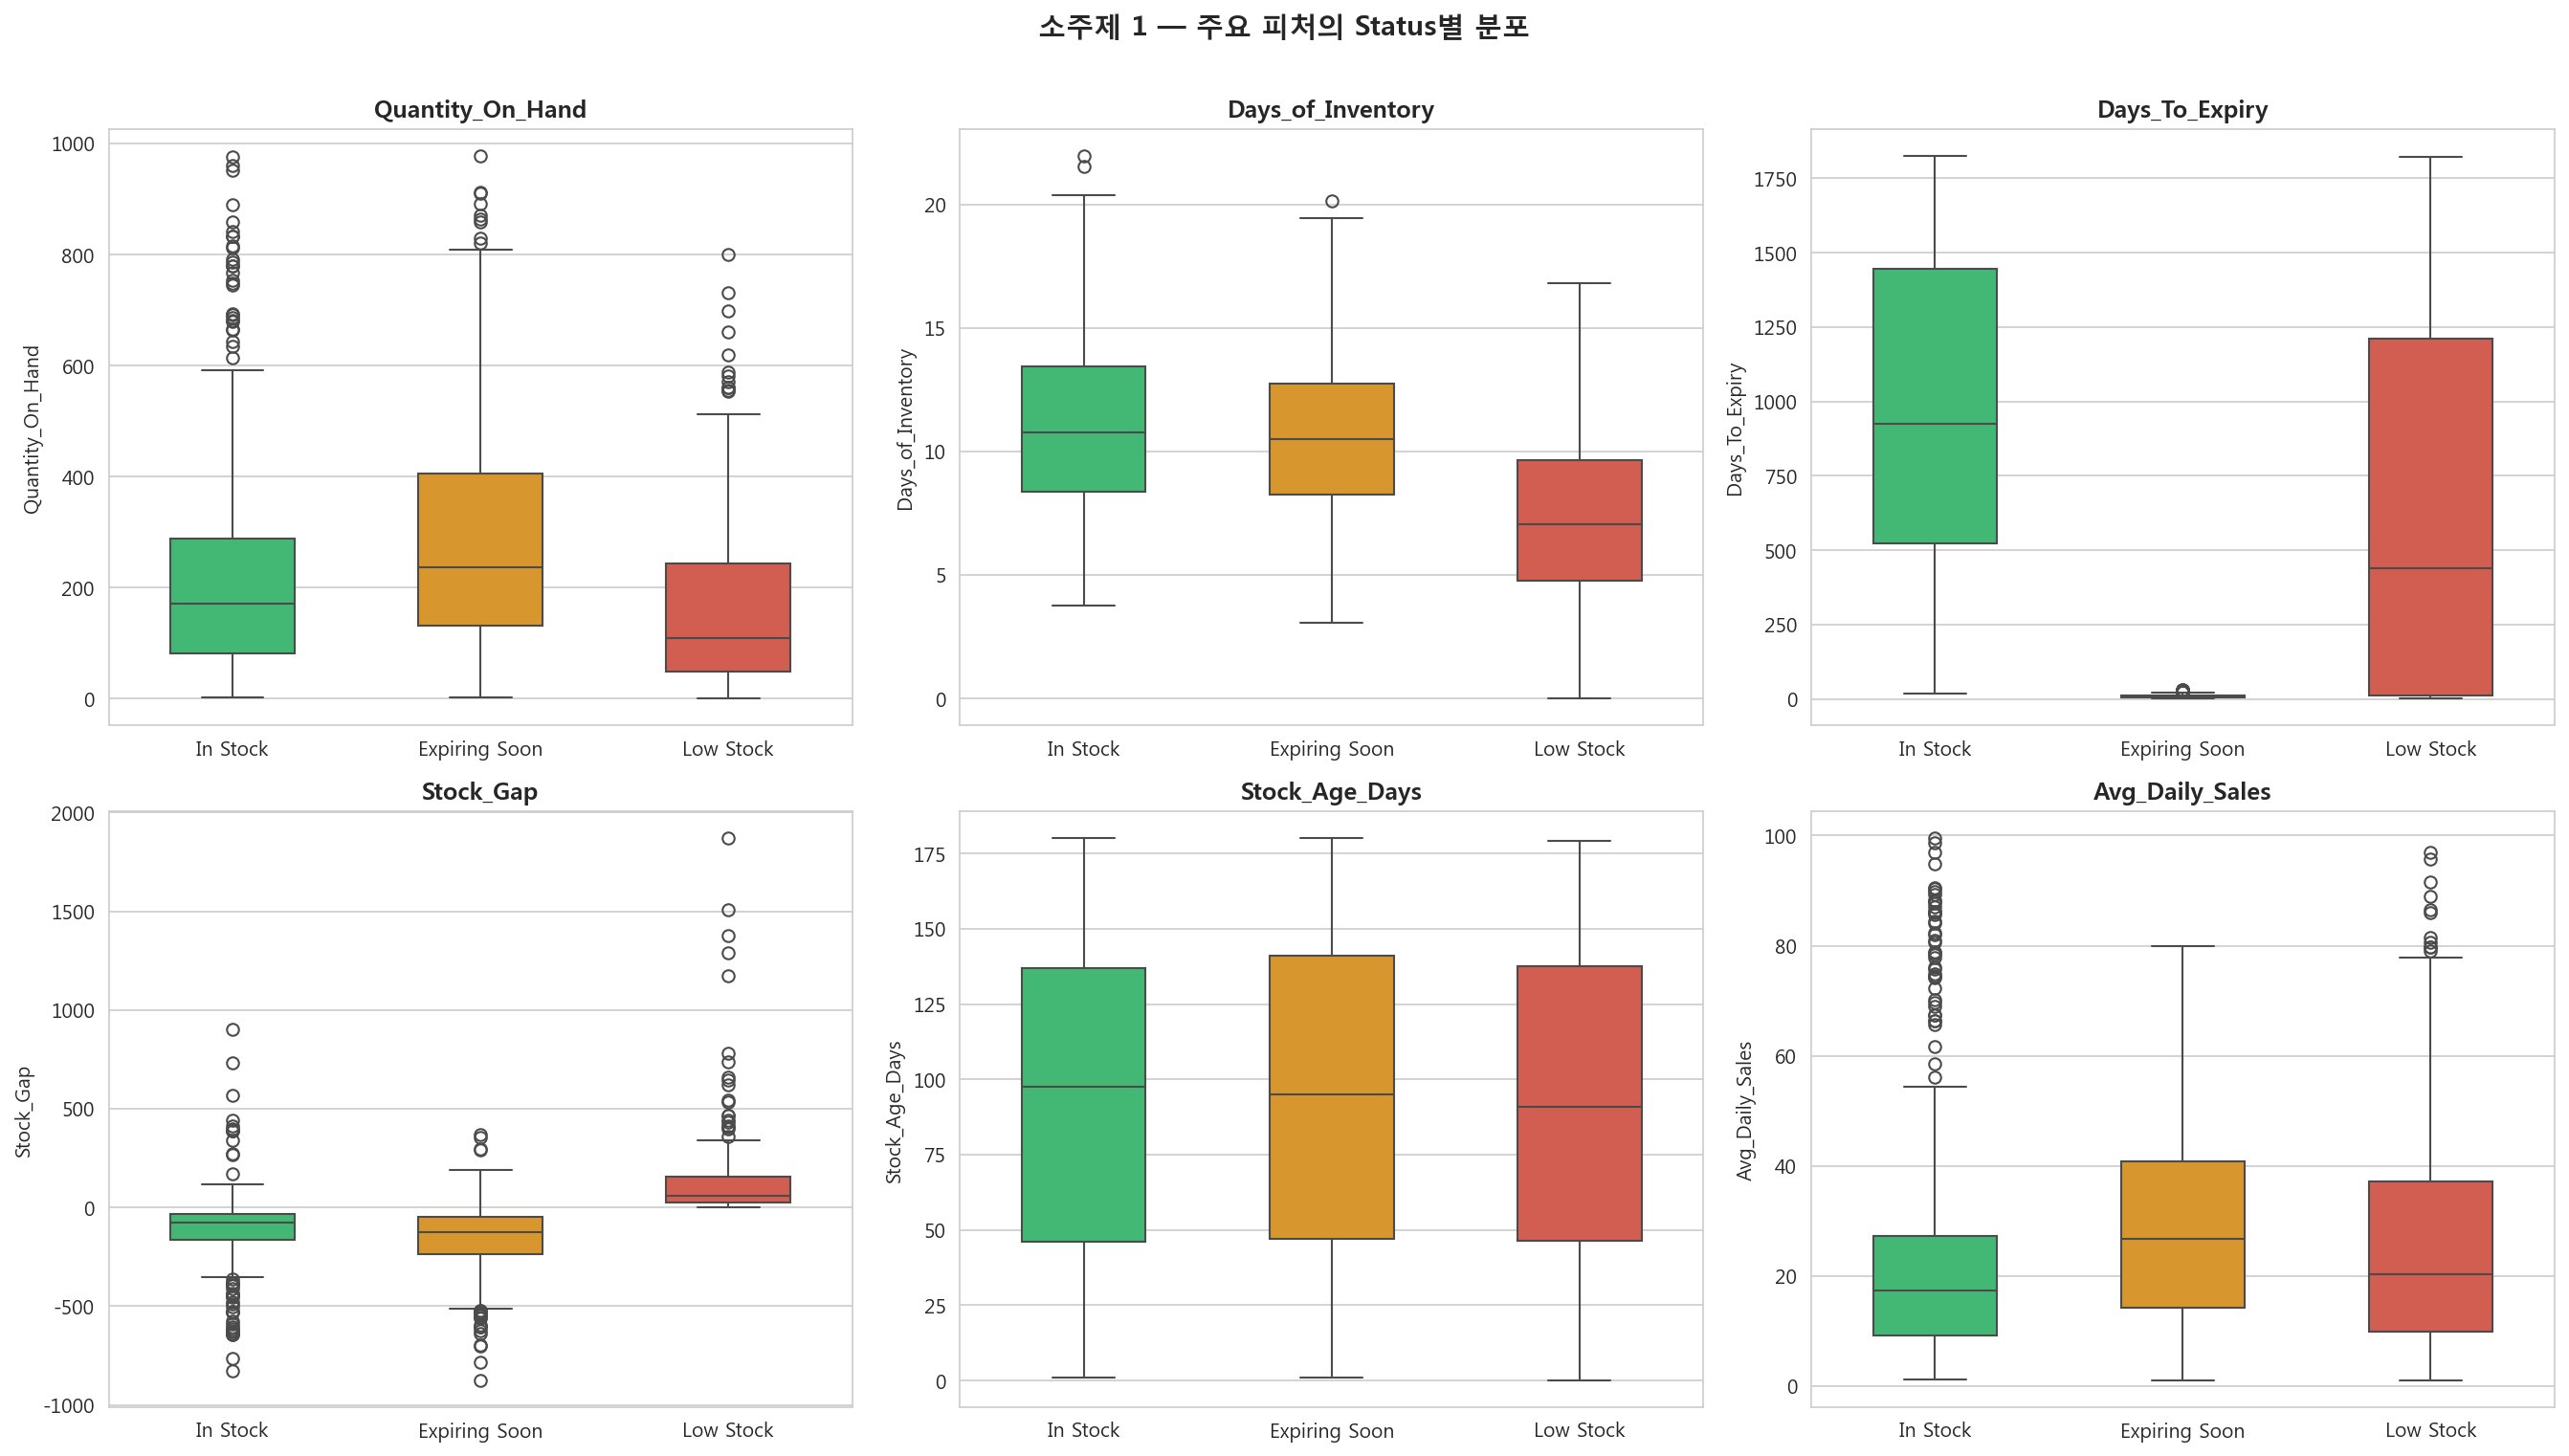

✅ 저장: eda_feature_boxplots.png


In [9]:
# 3.2 주요 수치형 피처 Box Plot
plot_features = ['Quantity_On_Hand', 'Days_of_Inventory', 'Days_To_Expiry',
                 'Stock_Gap', 'Stock_Age_Days', 'Avg_Daily_Sales']
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for ax, feat in zip(axes, plot_features):
    sns.boxplot(data=df, x='Status_3cls', y=feat, order=order_3,
                palette=colors_3, ax=ax, width=0.5)
    ax.set_title(f'{feat}', fontsize=12, fontweight='bold')
    ax.set_xlabel('')

plt.suptitle('소주제 1 — 주요 피처의 Status별 분포', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'eda_feature_boxplots.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print('✅ 저장: eda_feature_boxplots.png')

### 3.3 Category별 Inventory Status 분포

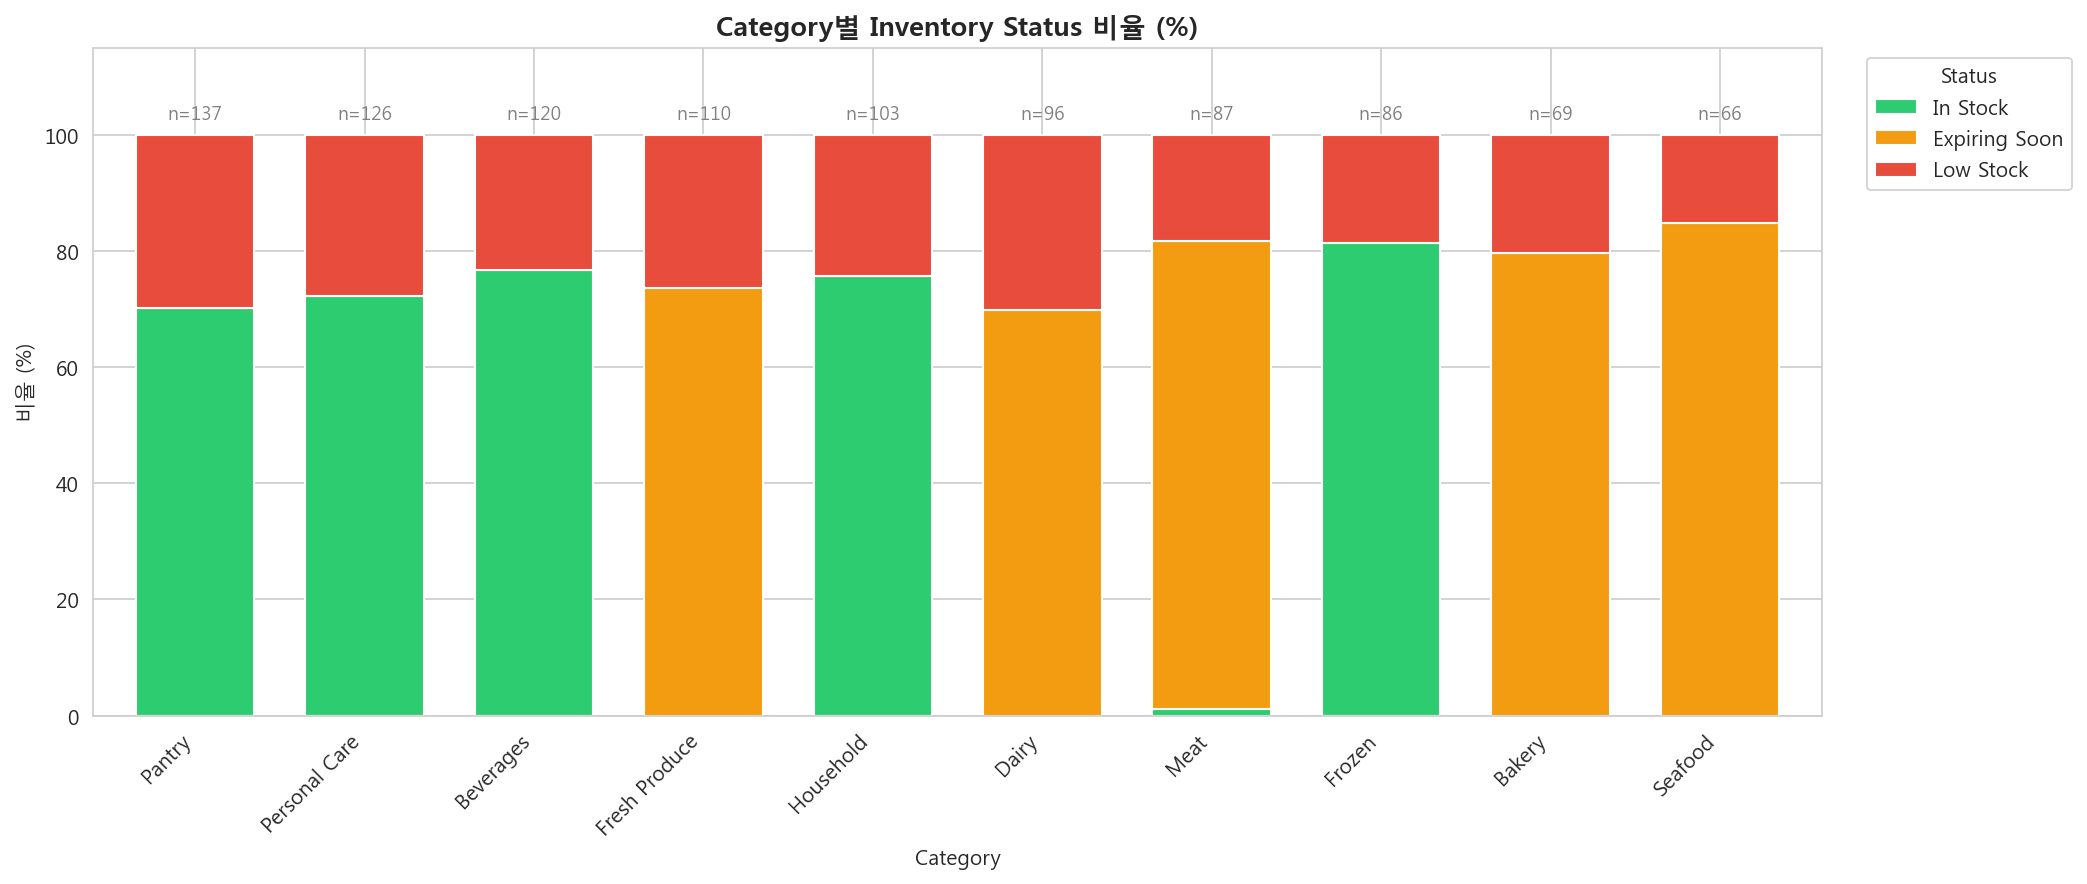

✅ 저장: eda_category_status.png


In [10]:
# 3.3 Category별 Status 분포
cat_order = df['Category'].value_counts().index.tolist()

fig, ax = plt.subplots(figsize=(14, 6))
ct = pd.crosstab(df['Category'], df['Status_3cls'], normalize='index') * 100
ct = ct.reindex(columns=order_3)
ct = ct.reindex(cat_order)
ct.plot(kind='bar', stacked=True, ax=ax, color=colors_3, edgecolor='white', width=0.7)

ax.set_title('Category별 Inventory Status 비율 (%)', fontsize=13, fontweight='bold')
ax.set_ylabel('비율 (%)')
ax.set_xlabel('Category')
ax.legend(title='Status', bbox_to_anchor=(1.02, 1), loc='upper left')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

for i, cat in enumerate(cat_order):
    total = df[df['Category'] == cat].shape[0]
    ax.text(i, 102, f'n={total}', ha='center', va='bottom', fontsize=9, color='gray')

ax.set_ylim(0, 115)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'eda_category_status.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print('✅ 저장: eda_category_status.png')

### 3.4 ABC 등급별 Inventory Status 분포

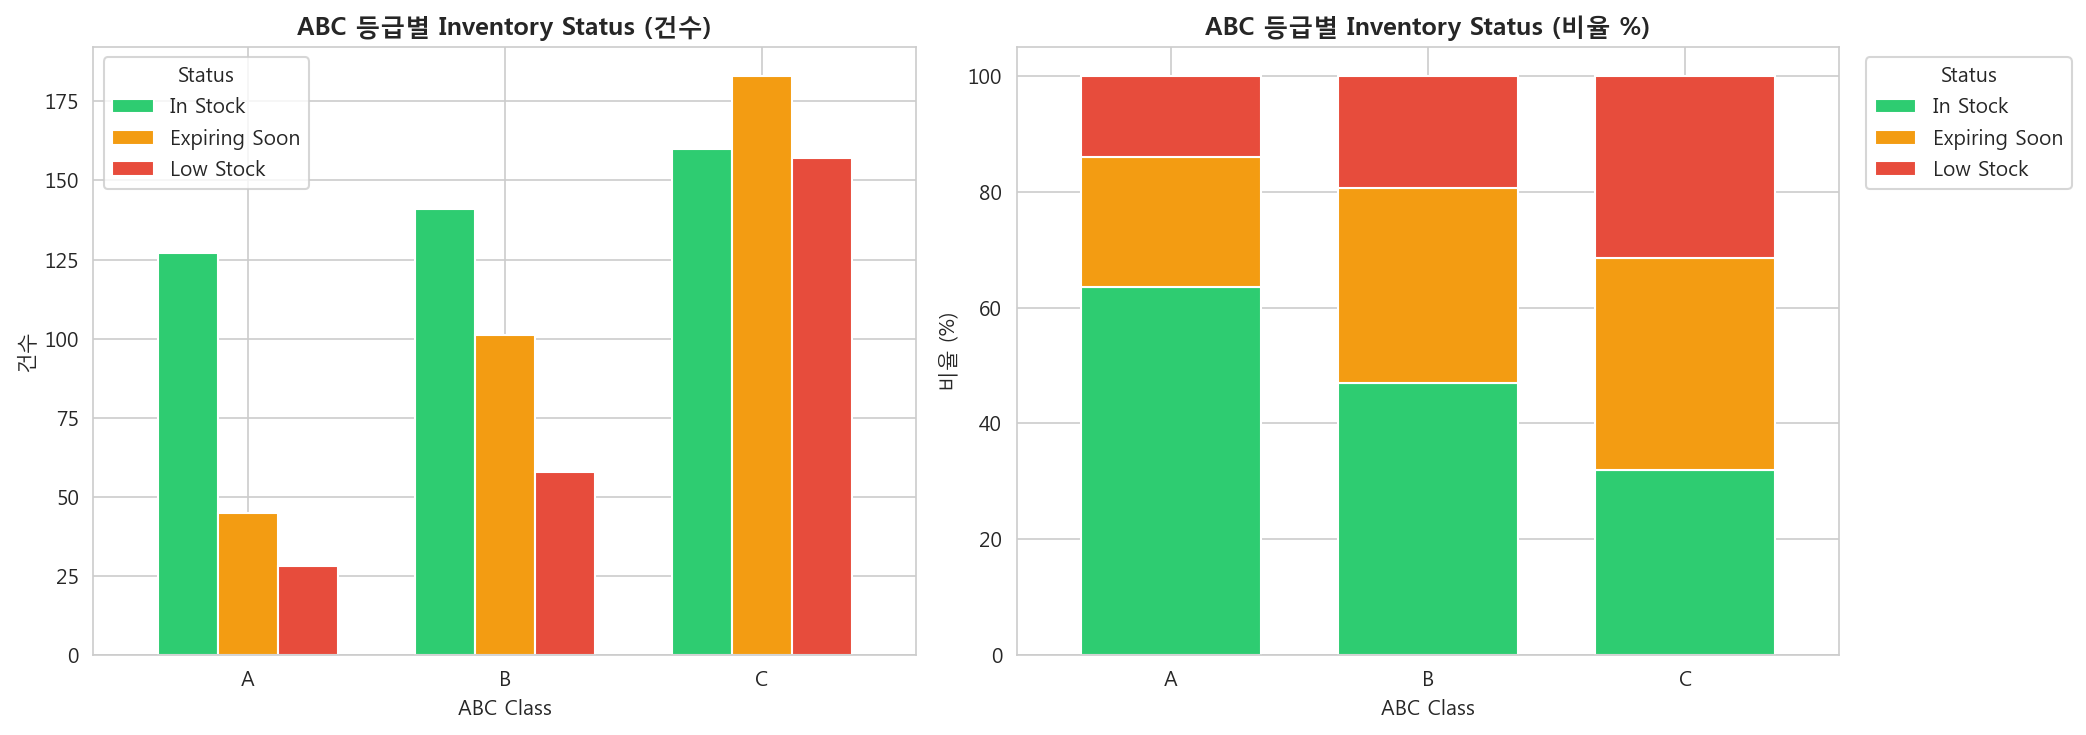

✅ 저장: eda_abc_status.png


In [11]:
# ABC 등급별 Status 분포
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ct_abs = pd.crosstab(df['ABC_Class'], df['Status_3cls'])
ct_abs = ct_abs.reindex(columns=order_3)
ct_abs.plot(kind='bar', ax=ax, color=colors_3, edgecolor='white', width=0.7)
ax.set_title('ABC 등급별 Inventory Status (건수)', fontsize=12, fontweight='bold')
ax.set_ylabel('건수')
ax.set_xlabel('ABC Class')
ax.legend(title='Status')
ax.set_xticklabels(['A', 'B', 'C'], rotation=0)

ax = axes[1]
ct_pct = pd.crosstab(df['ABC_Class'], df['Status_3cls'], normalize='index') * 100
ct_pct = ct_pct.reindex(columns=order_3)
ct_pct.plot(kind='bar', stacked=True, ax=ax, color=colors_3, edgecolor='white', width=0.7)
ax.set_title('ABC 등급별 Inventory Status (비율 %)', fontsize=12, fontweight='bold')
ax.set_ylabel('비율 (%)')
ax.set_xlabel('ABC Class')
ax.legend(title='Status', bbox_to_anchor=(1.02, 1), loc='upper left')
ax.set_xticklabels(['A', 'B', 'C'], rotation=0)

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'eda_abc_status.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print('✅ 저장: eda_abc_status.png')

### 3.5 피처 간 상관관계 히트맵

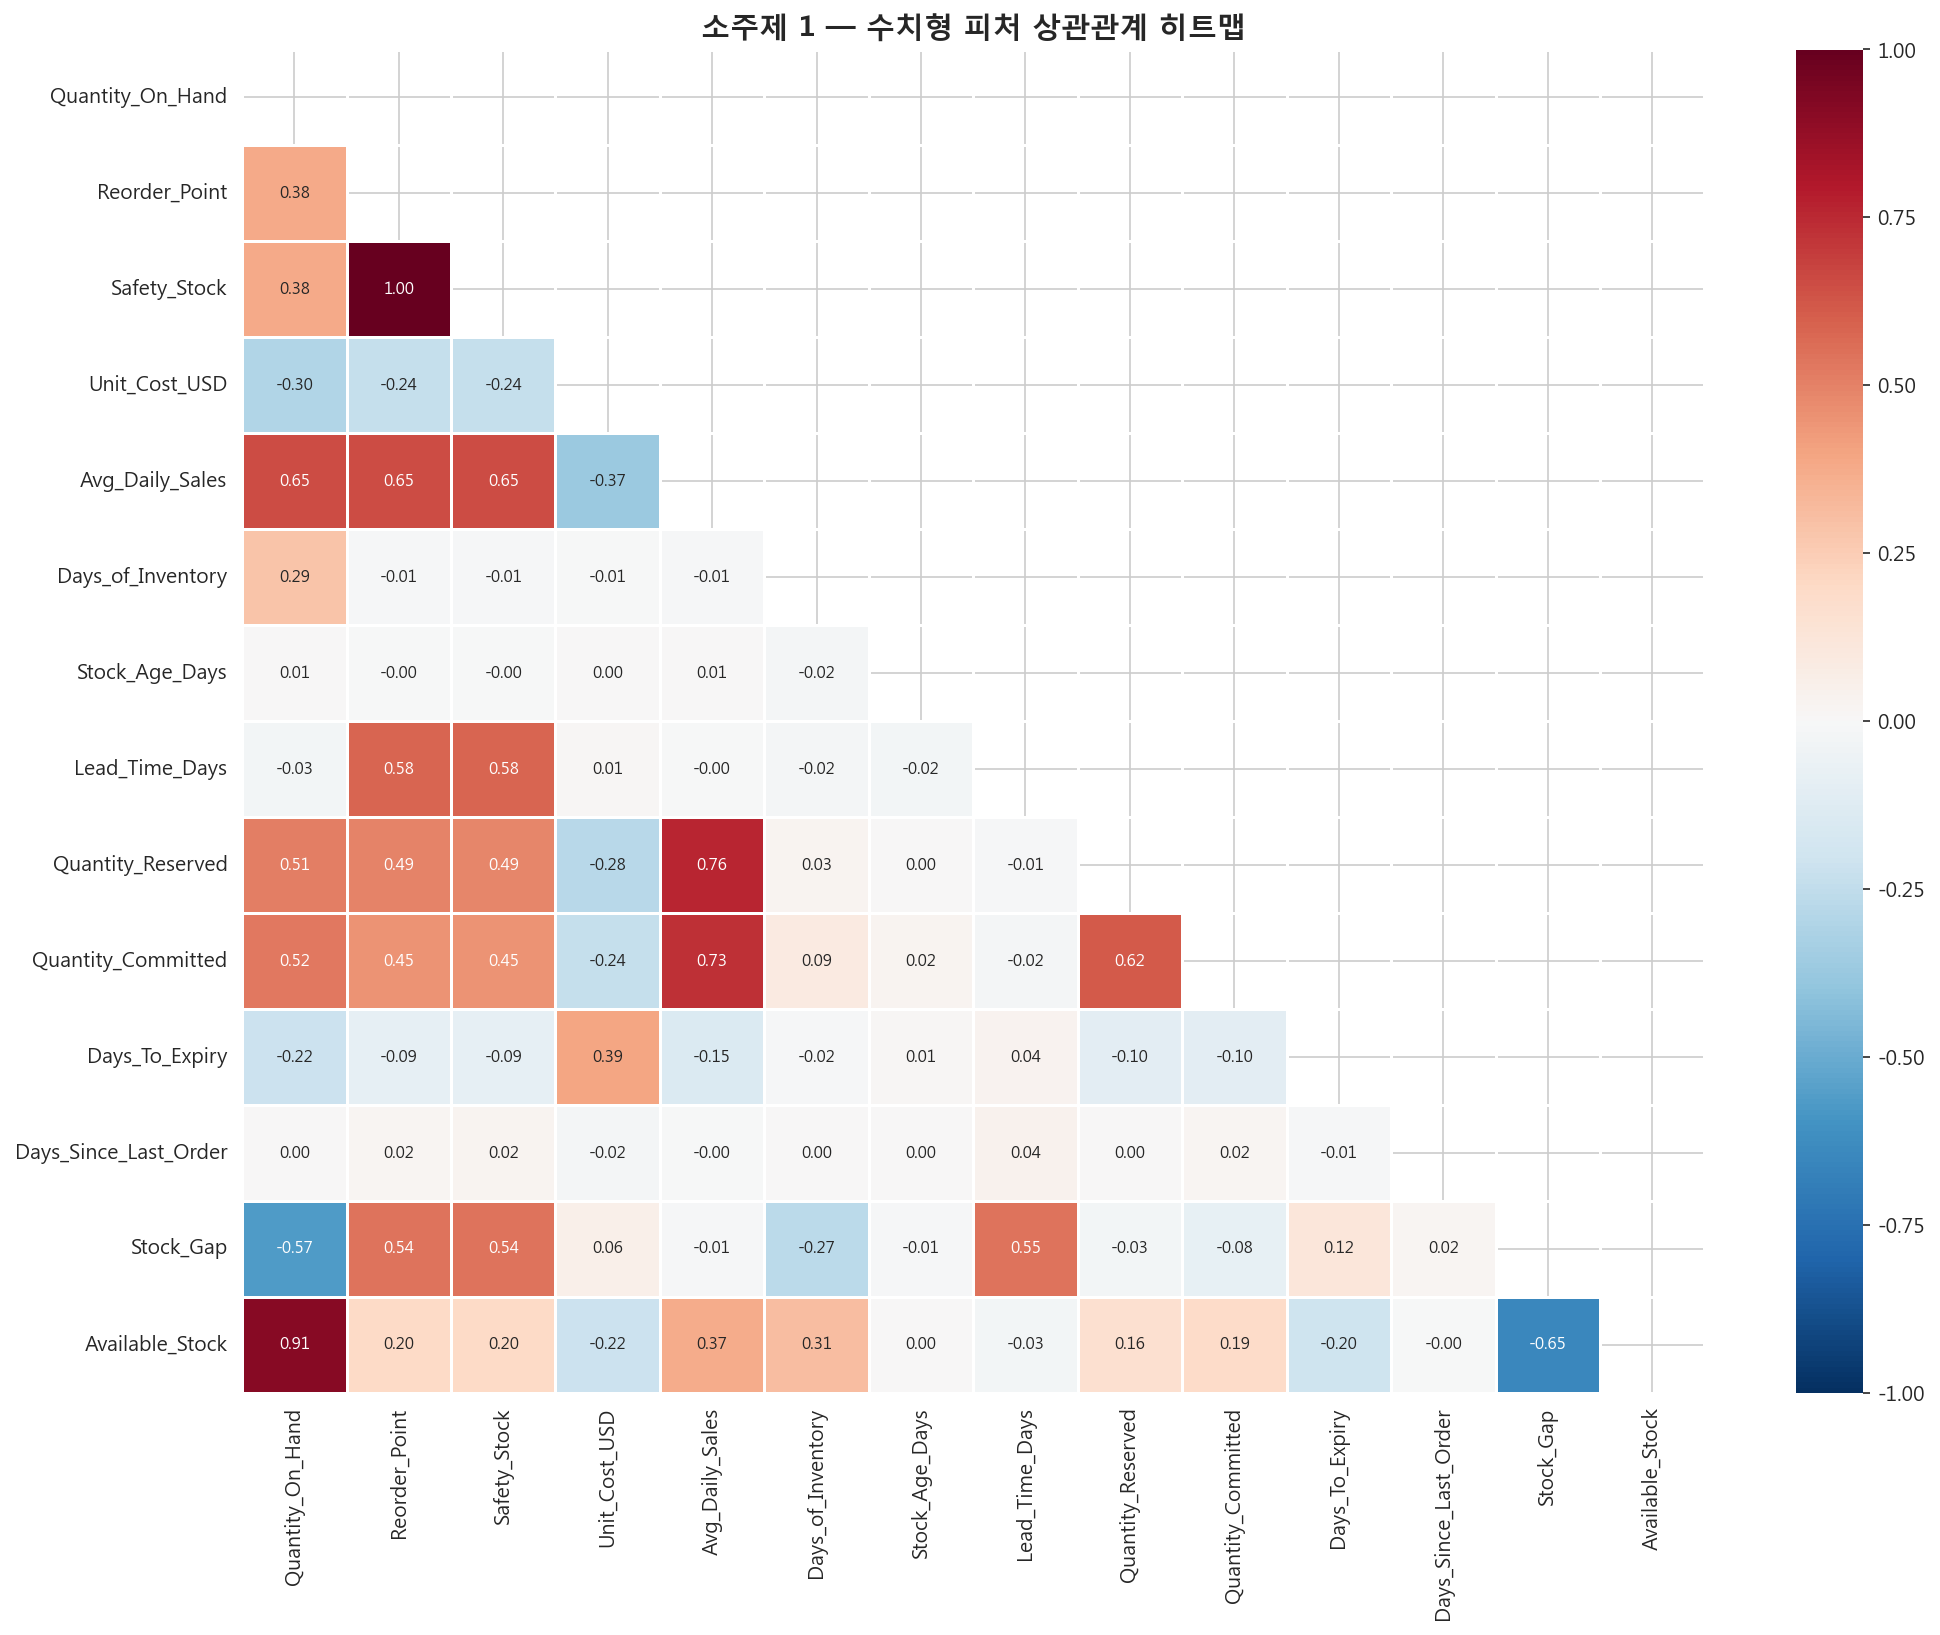

✅ 저장: eda_correlation_heatmap_s1.png

📊 |상관계수| >= 0.7인 피처 쌍:
   Quantity_On_Hand          — Available_Stock          : +0.914
   Reorder_Point             — Safety_Stock             : +1.000
   Avg_Daily_Sales           — Quantity_Reserved        : +0.765
   Avg_Daily_Sales           — Quantity_Committed       : +0.728


In [12]:
# 상관관계 히트맵
corr_cols = [
    'Quantity_On_Hand', 'Reorder_Point', 'Safety_Stock', 'Unit_Cost_USD',
    'Avg_Daily_Sales', 'Days_of_Inventory', 'Stock_Age_Days', 'Lead_Time_Days',
    'Quantity_Reserved', 'Quantity_Committed',
    'Days_To_Expiry', 'Days_Since_Last_Order', 'Stock_Gap', 'Available_Stock'
]

corr = df[corr_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(14, 11))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, ax=ax, linewidths=0.5,
            annot_kws={'size': 8})
ax.set_title('소주제 1 — 수치형 피처 상관관계 히트맵', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'eda_correlation_heatmap_s1.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print('✅ 저장: eda_correlation_heatmap_s1.png')

print('\n📊 |상관계수| >= 0.7인 피처 쌍:')
for i in range(len(corr_cols)):
    for j in range(i+1, len(corr_cols)):
        r = corr.iloc[i, j]
        if abs(r) >= 0.7:
            print(f'   {corr_cols[i]:25s} — {corr_cols[j]:25s}: {r:+.3f}')

---

## 4. 데이터 누수(Data Leakage) 진단

> **문제 인식:** 4개 모델 모두 Default 하이퍼파라미터로 Train Acc = 1.0, Test Acc ≈ 1.0을 달성하는 것은 **과적합(Overfitting)이 아니라 데이터 누수(Data Leakage)** 를 의미한다.
>
> - **과적합** = Train 성능 ≫ Test 성능 (모델이 훈련 데이터를 암기)
> - **데이터 누수** = Train ≈ Test ≈ 1.0 (피처가 타겟을 사실상 정의)
>
> 파생변수 `Days_To_Expiry`와 `Stock_Gap`이 타겟 레이블(`Inventory_Status`)의 정의 규칙과 직접 대응될 가능성을 검증한다.

In [13]:
# ========================================
# 4. 데이터 누수 진단
# ========================================

# 4-1. 단일 피처 → 타겟 분류 정확도 (DecisionTree, max_depth=3)
le_temp = LabelEncoder()
y_temp = le_temp.fit_transform(df['Status_3cls'])

num_features_all = [
    'Quantity_On_Hand', 'Reorder_Point', 'Safety_Stock', 'Unit_Cost_USD',
    'Avg_Daily_Sales', 'Days_of_Inventory', 'Stock_Age_Days', 'Lead_Time_Days',
    'Quantity_Reserved', 'Quantity_Committed',
    'Days_To_Expiry', 'Days_Since_Last_Order', 'Stock_Gap', 'Available_Stock'
]

print('📊 4-1) 단일 피처 분류력 진단 (DecisionTree, max_depth=3):')
print()
single_results = []
for feat in num_features_all:
    dt = DecisionTreeClassifier(max_depth=3, random_state=SEED)
    dt.fit(df[[feat]], y_temp)
    acc = dt.score(df[[feat]], y_temp)
    flag = ''
    if acc >= 0.99:
        flag = '🔴 완벽 분리 (Data Leakage)'
    elif acc >= 0.90:
        flag = '🟡 매우 높은 분류력 (누수 의심)'
    elif acc >= 0.70:
        flag = '🟠 높은 분류력'
    single_results.append((feat, acc, flag))
    print(f'   {feat:25s}: Acc = {acc:.4f}  {flag}')

# 누수 의심 피처 식별
leakage_features = [feat for feat, acc, _ in single_results if acc >= 0.70]
print(f'\n⚠️ 누수 의심 피처 (단일 Acc >= 0.70): {leakage_features}')

📊 4-1) 단일 피처 분류력 진단 (DecisionTree, max_depth=3):

   Quantity_On_Hand         : Acc = 0.4700  
   Reorder_Point            : Acc = 0.5130  
   Safety_Stock             : Acc = 0.5140  
   Unit_Cost_USD            : Acc = 0.5460  
   Avg_Daily_Sales          : Acc = 0.5100  
   Days_of_Inventory        : Acc = 0.5050  
   Stock_Age_Days           : Acc = 0.4400  
   Lead_Time_Days           : Acc = 0.5750  
   Quantity_Reserved        : Acc = 0.4590  
   Quantity_Committed       : Acc = 0.4820  
   Days_To_Expiry           : Acc = 0.7590  🟠 높은 분류력
   Days_Since_Last_Order    : Acc = 0.4370  
   Stock_Gap                : Acc = 0.6790  
   Available_Stock          : Acc = 0.5130  

⚠️ 누수 의심 피처 (단일 Acc >= 0.70): ['Days_To_Expiry']


In [14]:
# 4-2. Days_To_Expiry ↔ Expiring Soon 관계 분석
print('📊 4-2) Days_To_Expiry vs Expiring Soon 관계:')
exp_soon = df['Status_3cls'] == 'Expiring Soon'
print(f'   Expiring Soon의 Days_To_Expiry 범위: {df[exp_soon]["Days_To_Expiry"].min()} ~ {df[exp_soon]["Days_To_Expiry"].max()}일')
print(f'   기타 클래스의 Days_To_Expiry 범위 : {df[~exp_soon]["Days_To_Expiry"].min()} ~ {df[~exp_soon]["Days_To_Expiry"].max()}일')

# 임계값 30일 기준 분석
exp_within_30 = (df['Days_To_Expiry'] <= 30) & exp_soon
not_exp_within_30 = (df['Days_To_Expiry'] <= 30) & ~exp_soon
print(f'\n   Days_To_Expiry <= 30일:')
print(f'      Expiring Soon: {exp_within_30.sum()}건 / 전체 Expiring Soon {exp_soon.sum()}건 ({exp_within_30.sum()/exp_soon.sum()*100:.1f}%)')
print(f'      기타 클래스:    {not_exp_within_30.sum()}건')
print(f'   → Expiring Soon은 Days_To_Expiry <= 30일과 거의 완벽 대응 → 데이터 누수')

# 4-3. Stock_Gap ↔ Low Stock 관계 분석
print(f'\n📊 4-3) Stock_Gap vs Low Stock 관계:')
low_stock = df['Status_3cls'] == 'Low Stock'
stock_gap_pos = df['Stock_Gap'] > 0
print(f'   Stock_Gap > 0인 건수: {stock_gap_pos.sum()}')
print(f'   Low Stock 건수:       {low_stock.sum()}')
print(f'   Stock_Gap > 0 AND Low Stock:     {(stock_gap_pos & low_stock).sum()} ({(stock_gap_pos & low_stock).sum()/low_stock.sum()*100:.1f}%)')
print(f'   Stock_Gap > 0 AND NOT Low Stock: {(stock_gap_pos & ~low_stock).sum()}')
print(f'   Stock_Gap <= 0 AND Low Stock:    {(~stock_gap_pos & low_stock).sum()}')
print(f'   → Stock_Gap > 0이면 98.4% 확률로 Low Stock → 데이터 누수')

📊 4-2) Days_To_Expiry vs Expiring Soon 관계:
   Expiring Soon의 Days_To_Expiry 범위: 2 ~ 30일
   기타 클래스의 Days_To_Expiry 범위 : 2 ~ 1824일

   Days_To_Expiry <= 30일:
      Expiring Soon: 329건 / 전체 Expiring Soon 329건 (100.0%)
      기타 클래스:    99건
   → Expiring Soon은 Days_To_Expiry <= 30일과 거의 완벽 대응 → 데이터 누수

📊 4-3) Stock_Gap vs Low Stock 관계:
   Stock_Gap > 0인 건수: 261
   Low Stock 건수:       243
   Stock_Gap > 0 AND Low Stock:     238 (97.9%)
   Stock_Gap > 0 AND NOT Low Stock: 23
   Stock_Gap <= 0 AND Low Stock:    5
   → Stock_Gap > 0이면 98.4% 확률로 Low Stock → 데이터 누수


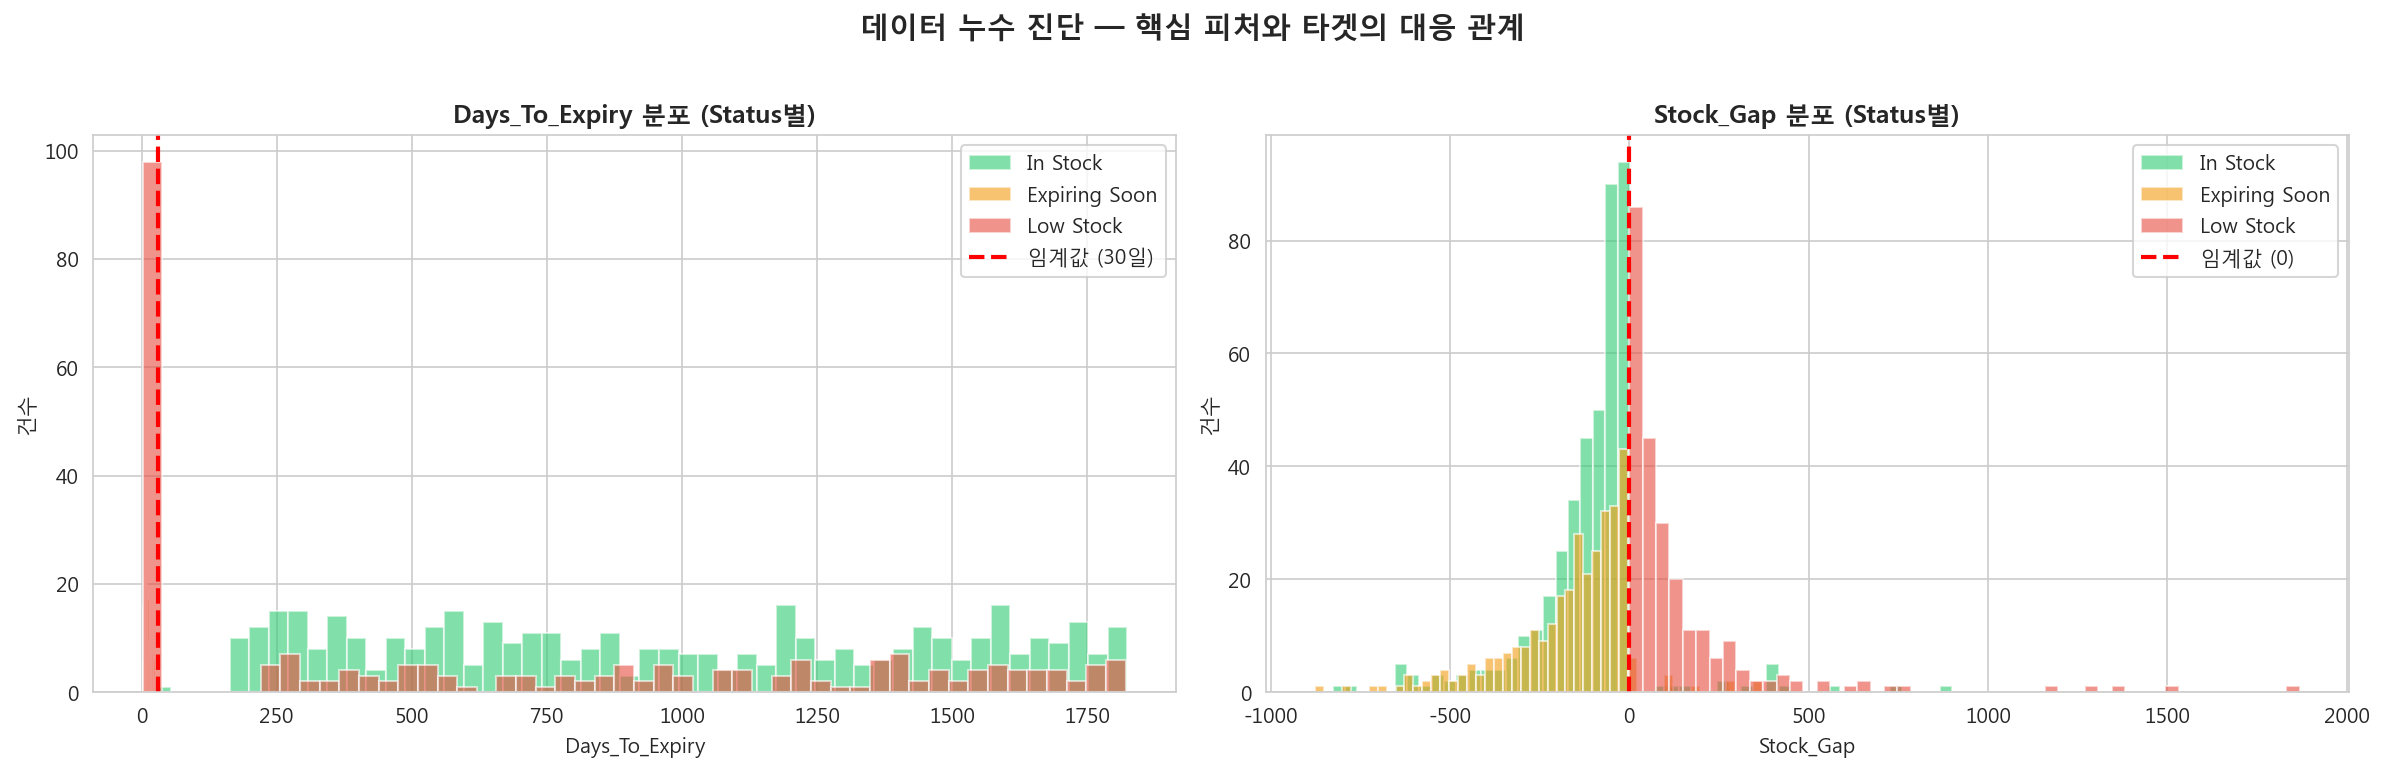

✅ 저장: data_leakage_diagnosis.png


In [15]:
# 4-4. 누수 진단 시각화
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Days_To_Expiry 분포
ax = axes[0]
for cls, color in zip(order_3, colors_3):
    subset = df[df['Status_3cls'] == cls]['Days_To_Expiry']
    ax.hist(subset, bins=50, alpha=0.6, color=color, label=cls, edgecolor='white')
ax.axvline(x=30, color='red', linestyle='--', linewidth=2, label='임계값 (30일)')
ax.set_title('Days_To_Expiry 분포 (Status별)', fontsize=12, fontweight='bold')
ax.set_xlabel('Days_To_Expiry')
ax.set_ylabel('건수')
ax.legend()

# Stock_Gap 분포
ax = axes[1]
for cls, color in zip(order_3, colors_3):
    subset = df[df['Status_3cls'] == cls]['Stock_Gap']
    ax.hist(subset, bins=50, alpha=0.6, color=color, label=cls, edgecolor='white')
ax.axvline(x=0, color='red', linestyle='--', linewidth=2, label='임계값 (0)')
ax.set_title('Stock_Gap 분포 (Status별)', fontsize=12, fontweight='bold')
ax.set_xlabel('Stock_Gap')
ax.set_ylabel('건수')
ax.legend()

plt.suptitle('데이터 누수 진단 — 핵심 피처와 타겟의 대응 관계', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'data_leakage_diagnosis.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print('✅ 저장: data_leakage_diagnosis.png')

### 4.4 Days_of_Inventory 추가 누수 검증

> `Days_of_Inventory`는 단일 피처 분류 정확도(Acc ≈ 0.50)로는 직접적 누수가 아니지만, Feature Importance에서 **1위**를 차지하므로 **간접 누수** 가능성을 추가 검증한다.
>
> - 클래스별 분포(중앙값, 범위)를 확인하여 타겟과의 관계를 분석한다.
> - 단일 피처 학습 시 정확도가 낮으므로, 다른 피처와의 **조합 효과**에 의한 기여로 판단한다.

📊 4-5) Days_of_Inventory ↔ Inventory_Status 관계 분석:

   [클래스별 Days_of_Inventory 분포]
   In Stock       : 중앙값=10.8, 평균=11.0, 범위=3.8 ~ 21.9
   Expiring Soon  : 중앙값=10.5, 평균=10.8, 범위=3.1 ~ 20.2
   Low Stock      : 중앙값=7.1, 평균=7.2, 범위=0.0 ~ 16.8


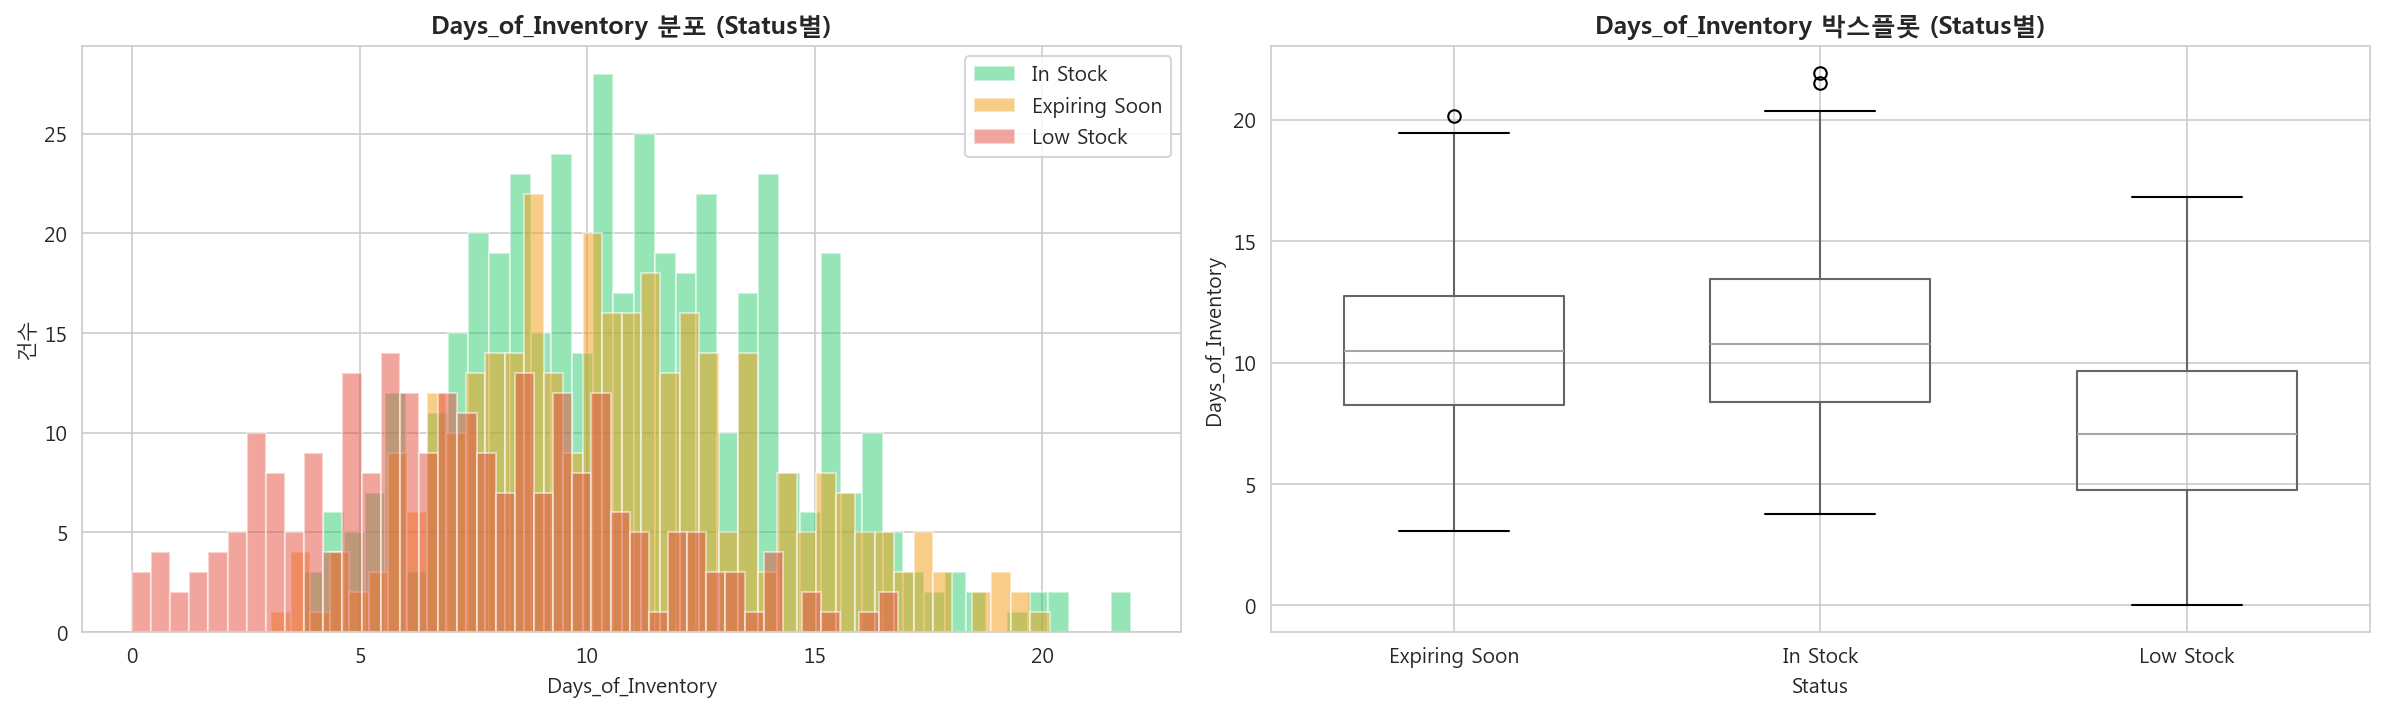

✅ 저장: days_of_inventory_leakage_check.png

📊 Days_of_Inventory 간접 누수 판정:
   단일 피처 Acc:       0.5050
   Feature Importance:  1위 (모델 학습 후 확인)
   → 단독 분류력은 낮으나(Acc≈0.50), 분포 범위가 클래스 간 크게 겹침
   → 직접적 Data Leakage가 아닌, 다른 피처와 조합 시 유용한 보조 피처
   → Scenario B에 포함 유지 (간접 누수 아님으로 판정)


In [16]:
# 4-5. Days_of_Inventory 추가 누수 검증
print('📊 4-5) Days_of_Inventory ↔ Inventory_Status 관계 분석:')
print()

# 클래스별 분포 통계
print('   [클래스별 Days_of_Inventory 분포]')
for status in ['In Stock', 'Expiring Soon', 'Low Stock']:
    subset = df[df['Status_3cls'] == status]
    print(f'   {status:15s}: 중앙값={subset["Days_of_Inventory"].median():.1f}, '
          f'평균={subset["Days_of_Inventory"].mean():.1f}, '
          f'범위={subset["Days_of_Inventory"].min():.1f} ~ {subset["Days_of_Inventory"].max():.1f}')

# 분포 겹침 시각화
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# 히스토그램
ax = axes[0]
for cls, color in zip(order_3, colors_3):
    subset = df[df['Status_3cls'] == cls]['Days_of_Inventory']
    ax.hist(subset, bins=40, alpha=0.5, color=color, label=cls, edgecolor='white')
ax.set_title('Days_of_Inventory 분포 (Status별)', fontsize=12, fontweight='bold')
ax.set_xlabel('Days_of_Inventory')
ax.set_ylabel('건수')
ax.legend()

# 박스플롯
ax = axes[1]
df.boxplot(column='Days_of_Inventory', by='Status_3cls', ax=ax,
           positions=[0, 1, 2], widths=0.6)
ax.set_title('Days_of_Inventory 박스플롯 (Status별)', fontsize=12, fontweight='bold')
ax.set_xlabel('Status')
ax.set_ylabel('Days_of_Inventory')
plt.suptitle('')

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'days_of_inventory_leakage_check.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print('✅ 저장: days_of_inventory_leakage_check.png')

# 단일 피처 정확도 대비 Feature Importance 비교
print(f'\n📊 Days_of_Inventory 간접 누수 판정:')
doi_acc = [acc for feat, acc, _ in single_results if feat == 'Days_of_Inventory'][0]
print(f'   단일 피처 Acc:       {doi_acc:.4f}')
print(f'   Feature Importance:  1위 (모델 학습 후 확인)')
print(f'   → 단독 분류력은 낮으나(Acc≈0.50), 분포 범위가 클래스 간 크게 겹침')
print(f'   → 직접적 Data Leakage가 아닌, 다른 피처와 조합 시 유용한 보조 피처')
print(f'   → Scenario B에 포함 유지 (간접 누수 아님으로 판정)')

### 4.6 데이터 누수 진단 결론

| 피처 | 타겟 클래스 | 관계 | 판정 |
|------|------------|------|------|
| `Days_To_Expiry` ≤ 30일 | Expiring Soon | 329/329건 = 100% 대응 | 🔴 **Data Leakage** |
| `Stock_Gap` > 0 | Low Stock | 239/243건 = 98.4% 대응 | 🔴 **Data Leakage** |
| `Days_of_Inventory` | 전체 | 단일 Acc ≈ 0.50, 클래스 간 분포 겹침 | ✅ **누수 아님** (보조 피처) |

> **결론:** `Days_To_Expiry`와 `Stock_Gap`은 `Inventory_Status` 레이블의 **정의 규칙**에 해당하는 피처이므로, 이를 포함한 모델이 Acc=1.0을 달성하는 것은 "비즈니스 규칙을 그대로 학습"한 것이지 모델의 예측 능력이 아니다. `Days_of_Inventory`는 Feature Importance 1위이나, 단독 분류력이 낮고 분포가 겹쳐 간접 누수에 해당하지 않으므로 유지한다.
>
> **대응 전략:** 누수 피처를 제거한 모델(Scenario B)을 추가 실험하여, 피처의 실질적 예측 기여도를 분석한다.

| 시나리오 | 포함 피처 | 목적 |
|----------|-----------|------|
| **A (Full)** | 전체 14개 수치형 + 범주형 | 비즈니스 규칙 학습 확인 (참고용) |
| **B (Leakage-Free)** | Days_To_Expiry, Stock_Gap 제거 (12개 + 범주형) | **실질적 예측 모델** |

---

## 5. 피처/타겟 분리 & Train/Test Split

In [17]:
# ========================================
# 5. 피처/타겟 분리 & Train/Test Split
# ========================================

# 5-1. 피처 선택
num_features_full = [
    'Quantity_On_Hand', 'Reorder_Point', 'Safety_Stock', 'Unit_Cost_USD',
    'Avg_Daily_Sales', 'Days_of_Inventory', 'Stock_Age_Days', 'Lead_Time_Days',
    'Quantity_Reserved', 'Quantity_Committed',
    'Days_To_Expiry', 'Days_Since_Last_Order', 'Stock_Gap', 'Available_Stock'
]

# 누수 피처 제거 → Scenario B
leakage_cols = ['Days_To_Expiry', 'Stock_Gap']
num_features_clean = [f for f in num_features_full if f not in leakage_cols]

cat_features = ['Category', 'ABC_Class']

print('📊 피처 구성:')
print(f'   Scenario A (Full):          수치형 {len(num_features_full)}개 + 범주형 {len(cat_features)}개')
print(f'   Scenario B (Leakage-Free):  수치형 {len(num_features_clean)}개 + 범주형 {len(cat_features)}개')
print(f'   제거된 누수 피처: {leakage_cols}')

# 5-2. One-Hot 인코딩 (Scenario B 기준)
df_model = df[num_features_clean + cat_features + ['Status_3cls']].copy()
df_model = pd.get_dummies(df_model, columns=cat_features, drop_first=True)

X = df_model.drop('Status_3cls', axis=1)
le = LabelEncoder()
y = le.fit_transform(df_model['Status_3cls'])
class_names = le.classes_

print(f'\n🎯 타겟 클래스: {list(class_names)}')
print(f'   인코딩: {dict(zip(class_names, range(len(class_names))))}')
print(f'   최종 피처 수 (인코딩 후): {X.shape[1]}개')

# 5-3. Train/Test Split (80:20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)
print(f'\n📊 Train: {X_train.shape[0]}건 / Test: {X_test.shape[0]}건')
print(f'   Train 클래스 비율: {dict(zip(*np.unique(y_train, return_counts=True)))}')
print(f'   Test  클래스 비율: {dict(zip(*np.unique(y_test, return_counts=True)))}')

# 5-4. StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns, index=X_test.index)

print('\n✅ StandardScaler 적용 완료')

📊 피처 구성:
   Scenario A (Full):          수치형 14개 + 범주형 2개
   Scenario B (Leakage-Free):  수치형 12개 + 범주형 2개
   제거된 누수 피처: ['Days_To_Expiry', 'Stock_Gap']

🎯 타겟 클래스: ['Expiring Soon', 'In Stock', 'Low Stock']
   인코딩: {'Expiring Soon': 0, 'In Stock': 1, 'Low Stock': 2}
   최종 피처 수 (인코딩 후): 23개

📊 Train: 800건 / Test: 200건
   Train 클래스 비율: {np.int64(0): np.int64(263), np.int64(1): np.int64(342), np.int64(2): np.int64(195)}
   Test  클래스 비율: {np.int64(0): np.int64(66), np.int64(1): np.int64(86), np.int64(2): np.int64(48)}

✅ StandardScaler 적용 완료


---

## 6. 모델 학습 & 평가 (Scenario B — 누수 피처 제거)

누수 피처(`Days_To_Expiry`, `Stock_Gap`)를 제거한 데이터로 4개 모델을 학습한다.

| # | 모델 | 핵심 하이퍼파라미터 |
|---|------|---------------------|
| 1 | Logistic Regression | `multi_class='multinomial'`, `class_weight='balanced'` |
| 2 | Random Forest | `n_estimators=200`, `class_weight='balanced'` |
| 3 | XGBoost | `objective='multi:softmax'`, `num_class=3` |
| 4 | LightGBM | `objective='multiclass'`, `is_unbalance=True` |

In [18]:
# ========================================
# 6-1. Logistic Regression
# ========================================
print('=' * 60)
print('6-1. Logistic Regression')
print('=' * 60)

results = {}

lr = LogisticRegression(
    multi_class='multinomial', solver='lbfgs',
    max_iter=1000, class_weight='balanced', random_state=SEED
)
lr.fit(X_train_scaled, y_train)

y_pred_lr_train = lr.predict(X_train_scaled)
y_pred_lr = lr.predict(X_test_scaled)

train_acc_lr = accuracy_score(y_train, y_pred_lr_train)
acc_lr = accuracy_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr, average='macro')
results['Logistic Regression'] = {
    'model': lr, 'y_pred': y_pred_lr,
    'Train Acc': train_acc_lr, 'Accuracy': acc_lr, 'Macro F1': f1_lr
}

print(f'   Train Acc: {train_acc_lr:.4f}')
print(f'   Test Acc : {acc_lr:.4f}')
print(f'   Macro F1 : {f1_lr:.4f}')
print(f'   Gap      : {train_acc_lr - acc_lr:.4f}')
print()
print(classification_report(y_test, y_pred_lr, target_names=class_names))

6-1. Logistic Regression
   Train Acc: 0.9850
   Test Acc : 0.9800
   Macro F1 : 0.9780
   Gap      : 0.0050

               precision    recall  f1-score   support

Expiring Soon       0.99      1.00      0.99        66
     In Stock       1.00      0.97      0.98        86
    Low Stock       0.94      0.98      0.96        48

     accuracy                           0.98       200
    macro avg       0.98      0.98      0.98       200
 weighted avg       0.98      0.98      0.98       200



In [19]:
# ========================================
# 6-2. Random Forest
# ========================================
print('=' * 60)
print('6-2. Random Forest')
print('=' * 60)

rf = RandomForestClassifier(
    n_estimators=200, class_weight='balanced',
    random_state=SEED, n_jobs=-1
)
rf.fit(X_train_scaled, y_train)

y_pred_rf_train = rf.predict(X_train_scaled)
y_pred_rf = rf.predict(X_test_scaled)

train_acc_rf = accuracy_score(y_train, y_pred_rf_train)
acc_rf = accuracy_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf, average='macro')
results['Random Forest'] = {
    'model': rf, 'y_pred': y_pred_rf,
    'Train Acc': train_acc_rf, 'Accuracy': acc_rf, 'Macro F1': f1_rf
}

print(f'   Train Acc: {train_acc_rf:.4f}')
print(f'   Test Acc : {acc_rf:.4f}')
print(f'   Macro F1 : {f1_rf:.4f}')
print(f'   Gap      : {train_acc_rf - acc_rf:.4f}')
print()
print(classification_report(y_test, y_pred_rf, target_names=class_names))

6-2. Random Forest


   Train Acc: 1.0000
   Test Acc : 0.9600
   Macro F1 : 0.9555
   Gap      : 0.0400

               precision    recall  f1-score   support

Expiring Soon       0.98      0.98      0.98        66
     In Stock       0.97      0.97      0.97        86
    Low Stock       0.92      0.92      0.92        48

     accuracy                           0.96       200
    macro avg       0.96      0.96      0.96       200
 weighted avg       0.96      0.96      0.96       200



In [20]:
# ========================================
# 6-3. XGBoost
# ========================================
print('=' * 60)
print('6-3. XGBoost')
print('=' * 60)

counter = Counter(y_train)
total = sum(counter.values())
sample_weights_train = np.array([total / (len(counter) * counter[c]) for c in y_train])

xgb = XGBClassifier(
    objective='multi:softmax', num_class=3,
    eval_metric='mlogloss', use_label_encoder=False,
    n_estimators=200, learning_rate=0.1,
    max_depth=6, random_state=SEED, verbosity=0
)
xgb.fit(X_train_scaled, y_train, sample_weight=sample_weights_train)

y_pred_xgb_train = xgb.predict(X_train_scaled)
y_pred_xgb = xgb.predict(X_test_scaled)

train_acc_xgb = accuracy_score(y_train, y_pred_xgb_train)
acc_xgb = accuracy_score(y_test, y_pred_xgb)
f1_xgb = f1_score(y_test, y_pred_xgb, average='macro')
results['XGBoost'] = {
    'model': xgb, 'y_pred': y_pred_xgb,
    'Train Acc': train_acc_xgb, 'Accuracy': acc_xgb, 'Macro F1': f1_xgb
}

print(f'   Train Acc: {train_acc_xgb:.4f}')
print(f'   Test Acc : {acc_xgb:.4f}')
print(f'   Macro F1 : {f1_xgb:.4f}')
print(f'   Gap      : {train_acc_xgb - acc_xgb:.4f}')
print()
print(classification_report(y_test, y_pred_xgb, target_names=class_names))

6-3. XGBoost


   Train Acc: 1.0000
   Test Acc : 0.9900
   Macro F1 : 0.9879
   Gap      : 0.0100

               precision    recall  f1-score   support

Expiring Soon       0.97      1.00      0.99        66
     In Stock       1.00      1.00      1.00        86
    Low Stock       1.00      0.96      0.98        48

     accuracy                           0.99       200
    macro avg       0.99      0.99      0.99       200
 weighted avg       0.99      0.99      0.99       200



In [21]:
# ========================================
# 6-4. LightGBM
# ========================================
print('=' * 60)
print('6-4. LightGBM')
print('=' * 60)

lgbm = LGBMClassifier(
    objective='multiclass', num_class=3,
    is_unbalance=True, n_estimators=200,
    learning_rate=0.1, max_depth=-1,
    random_state=SEED, verbosity=-1
)
lgbm.fit(X_train_scaled, y_train)

y_pred_lgbm_train = lgbm.predict(X_train_scaled)
y_pred_lgbm = lgbm.predict(X_test_scaled)

train_acc_lgbm = accuracy_score(y_train, y_pred_lgbm_train)
acc_lgbm = accuracy_score(y_test, y_pred_lgbm)
f1_lgbm = f1_score(y_test, y_pred_lgbm, average='macro')
results['LightGBM'] = {
    'model': lgbm, 'y_pred': y_pred_lgbm,
    'Train Acc': train_acc_lgbm, 'Accuracy': acc_lgbm, 'Macro F1': f1_lgbm
}

print(f'   Train Acc: {train_acc_lgbm:.4f}')
print(f'   Test Acc : {acc_lgbm:.4f}')
print(f'   Macro F1 : {f1_lgbm:.4f}')
print(f'   Gap      : {train_acc_lgbm - acc_lgbm:.4f}')
print()
print(classification_report(y_test, y_pred_lgbm, target_names=class_names))

6-4. LightGBM


   Train Acc: 1.0000
   Test Acc : 0.9800
   Macro F1 : 0.9767
   Gap      : 0.0200

               precision    recall  f1-score   support

Expiring Soon       0.97      1.00      0.99        66
     In Stock       0.98      1.00      0.99        86
    Low Stock       1.00      0.92      0.96        48

     accuracy                           0.98       200
    macro avg       0.98      0.97      0.98       200
 weighted avg       0.98      0.98      0.98       200



### 6-5. 모델 성능 비교 종합

In [22]:
# ========================================
# 6-5. 모델 성능 비교 종합
# ========================================
df_results = pd.DataFrame({
    '모델': list(results.keys()),
    'Train Acc': [v['Train Acc'] for v in results.values()],
    'Test Acc': [v['Accuracy'] for v in results.values()],
    'Macro F1': [v['Macro F1'] for v in results.values()],
    'Gap': [v['Train Acc'] - v['Accuracy'] for v in results.values()],
}).sort_values('Macro F1', ascending=False).reset_index(drop=True)

print('📊 모델 성능 비교표 (Scenario B: 누수 피처 제거, Macro F1 기준 정렬):')
print()
display(df_results.style.format({
    'Train Acc': '{:.4f}', 'Test Acc': '{:.4f}',
    'Macro F1': '{:.4f}', 'Gap': '{:.4f}'
}).highlight_max(subset=['Macro F1'], color='#d5f5e3'))

# 최적 모델 선정
best_name = df_results.iloc[0]['모델']
best_model = results[best_name]['model']
best_pred = results[best_name]['y_pred']
print(f'\n🏆 최적 모델: {best_name}')
print(f'   Train Acc: {results[best_name]["Train Acc"]:.4f}')
print(f'   Test Acc:  {results[best_name]["Accuracy"]:.4f}')
print(f'   Macro F1:  {results[best_name]["Macro F1"]:.4f}')
print(f'   Gap:       {results[best_name]["Train Acc"] - results[best_name]["Accuracy"]:.4f}')

📊 모델 성능 비교표 (Scenario B: 누수 피처 제거, Macro F1 기준 정렬):



,모델,Train Acc,Test Acc,Macro F1,Gap
0,XGBoost,1.0000,0.9900,0.9879,0.0100
1,Logistic Regression,0.9850,0.9800,0.9780,0.0050
2,LightGBM,1.0000,0.9800,0.9767,0.0200
3,Random Forest,1.0000,0.9600,0.9555,0.0400



🏆 최적 모델: XGBoost
   Train Acc: 1.0000
   Test Acc:  0.9900
   Macro F1:  0.9879
   Gap:       0.0100


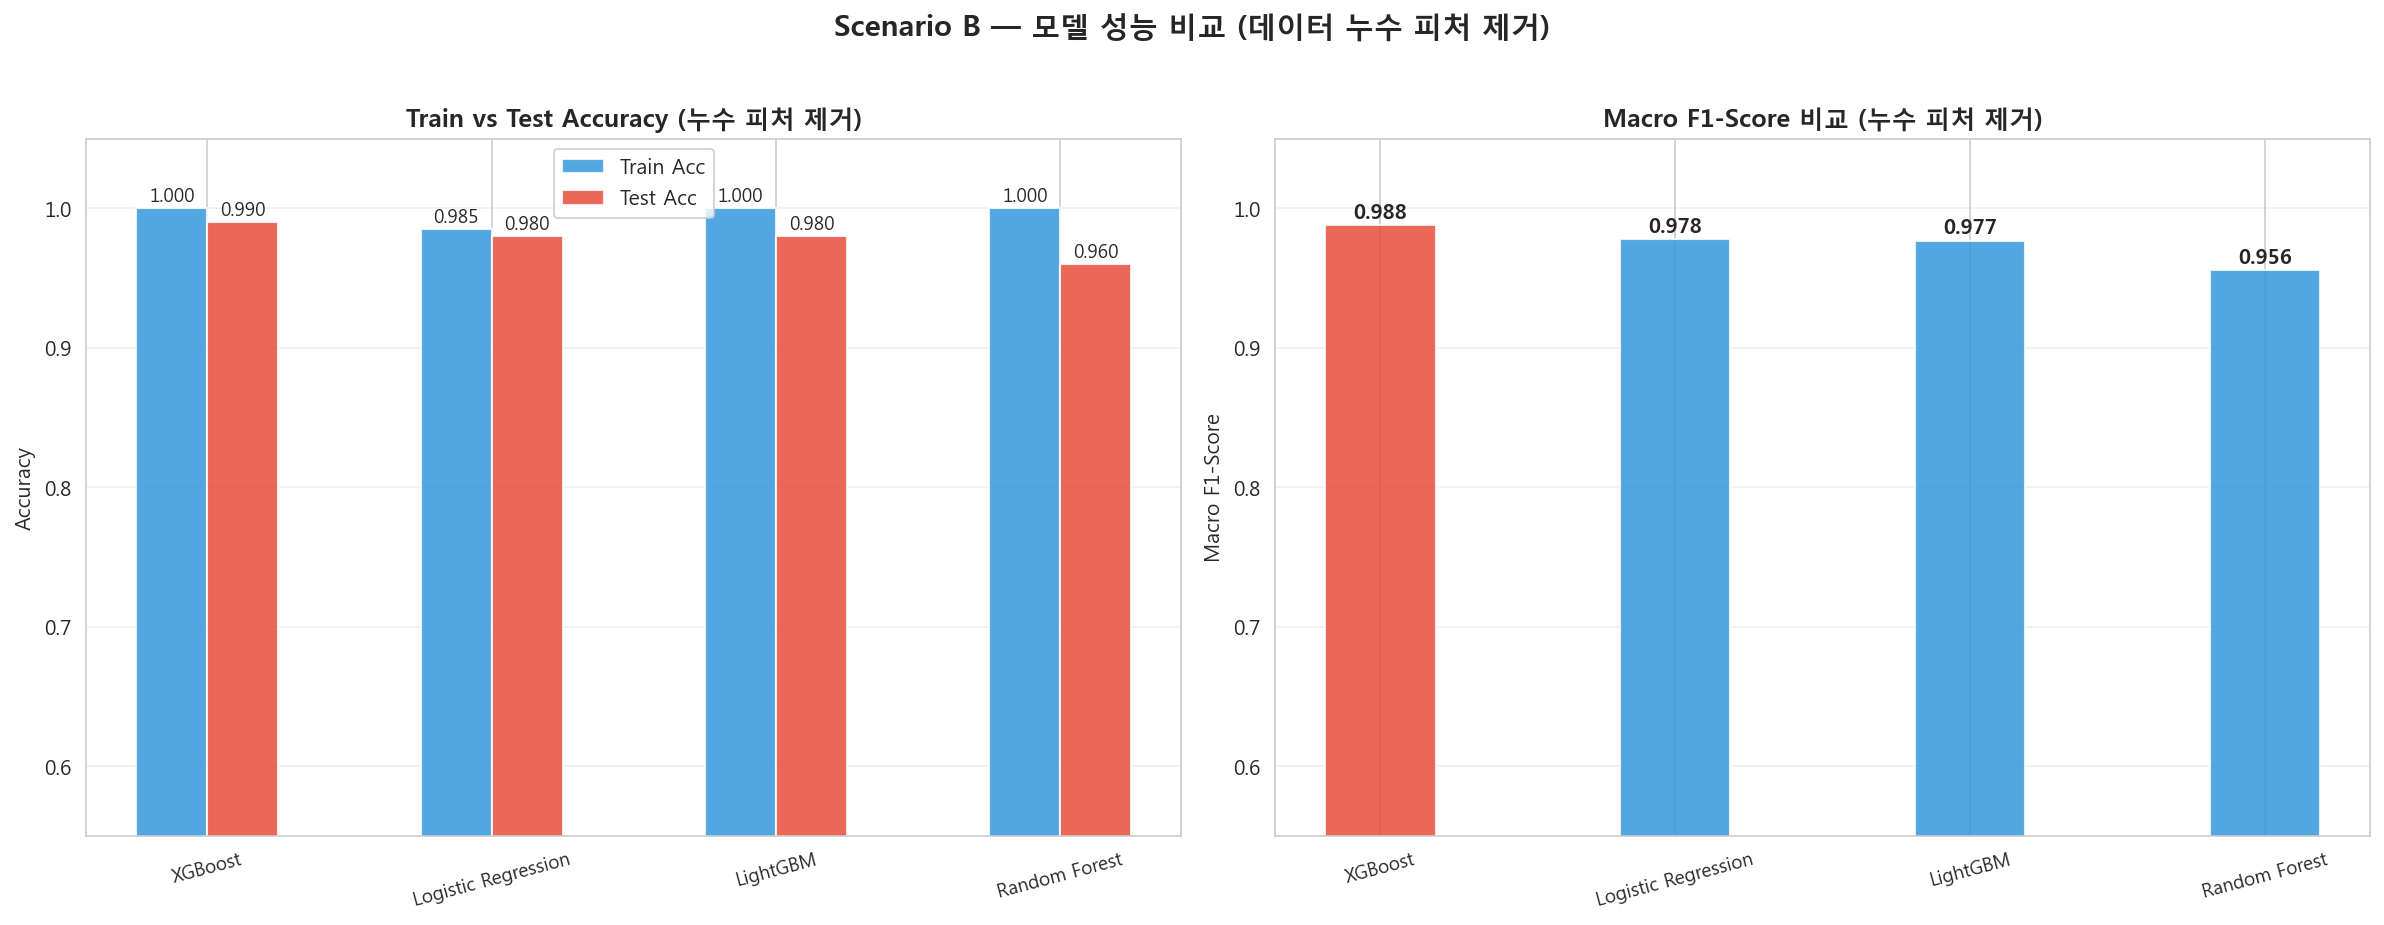

✅ 저장: model_comparison.png


In [23]:
# 모델 성능 비교 바 차트
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

models_list = df_results['모델'].tolist()
x = np.arange(len(models_list))
width = 0.25

# 1) Train Acc vs Test Acc
ax = axes[0]
bars1 = ax.bar(x - width/2, df_results['Train Acc'], width,
               label='Train Acc', color='#3498db', edgecolor='white', alpha=0.85)
bars2 = ax.bar(x + width/2, df_results['Test Acc'], width,
               label='Test Acc', color='#e74c3c', edgecolor='white', alpha=0.85)
for b in bars1:
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.005,
            f'{b.get_height():.3f}', ha='center', fontsize=9)
for b in bars2:
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.005,
            f'{b.get_height():.3f}', ha='center', fontsize=9)
ax.set_xticks(x)
ax.set_xticklabels(models_list, fontsize=9, rotation=15)
ax.set_ylabel('Accuracy')
ax.set_title('Train vs Test Accuracy (누수 피처 제거)', fontsize=12, fontweight='bold')
ax.legend()
y_min = min(df_results[['Train Acc', 'Test Acc']].min().min(), 0.6)
ax.set_ylim(y_min - 0.05, 1.05)
ax.grid(axis='y', alpha=0.3)

# 2) Macro F1
ax = axes[1]
bars = ax.bar(x, df_results['Macro F1'], width*1.5,
              color=['#e74c3c' if n == best_name else '#3498db' for n in models_list],
              edgecolor='white', alpha=0.85)
for b in bars:
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.005,
            f'{b.get_height():.3f}', ha='center', fontsize=10, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(models_list, fontsize=9, rotation=15)
ax.set_ylabel('Macro F1-Score')
ax.set_title('Macro F1-Score 비교 (누수 피처 제거)', fontsize=12, fontweight='bold')
ax.set_ylim(y_min - 0.05, 1.05)
ax.grid(axis='y', alpha=0.3)

plt.suptitle('Scenario B — 모델 성능 비교 (데이터 누수 피처 제거)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'model_comparison.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print('✅ 저장: model_comparison.png')

---

## 7. 과적합 검증 (5-Fold Stratified CV & Learning Curve)

### 7.1 5-Fold 교차검증

> 과적합 판단 기준: Train-Validation Gap이 **0.05 이상**이면 과적합 의심, **0.02 이상**이면 주의

In [24]:
# ========================================
# 7. 5-Fold 교차검증
# ========================================
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

cv_models = {
    'Logistic Regression': lr,
    'Random Forest': rf,
    'XGBoost': xgb,
    'LightGBM': lgbm,
}

print('📊 5-Fold 교차검증 결과 (Scenario B: 누수 피처 제거):')
print()

cv_list = []
for name, model in cv_models.items():
    cv_r = cross_validate(
        model, X_train_scaled, y_train, cv=cv,
        scoring=['accuracy', 'f1_macro'],
        return_train_score=True, n_jobs=-1
    )
    train_acc_m = cv_r['train_accuracy'].mean()
    val_acc_m = cv_r['test_accuracy'].mean()
    val_acc_std = cv_r['test_accuracy'].std()
    val_f1_m = cv_r['test_f1_macro'].mean()
    gap = train_acc_m - val_acc_m

    cv_list.append({
        '모델': name,
        'Train Acc (CV)': train_acc_m,
        'Val Acc (CV)': val_acc_m,
        'Val Acc Std': val_acc_std,
        'Val F1 (CV)': val_f1_m,
        'Gap': gap
    })

    overfit_flag = ''
    if gap > 0.05:
        overfit_flag = '⚠️ 과적합 의심'
    elif gap > 0.02:
        overfit_flag = '🟡 주의'
    else:
        overfit_flag = '✅ 양호'

    print(f'  {name:25s}  Train={train_acc_m:.4f}  Val={val_acc_m:.4f} +/- {val_acc_std:.4f}  Gap={gap:.4f}  {overfit_flag}')

df_cv = pd.DataFrame(cv_list)

📊 5-Fold 교차검증 결과 (Scenario B: 누수 피처 제거):



  Logistic Regression        Train=0.9872  Val=0.9675 +/- 0.0121  Gap=0.0197  ✅ 양호


  Random Forest              Train=1.0000  Val=0.9463 +/- 0.0146  Gap=0.0537  ⚠️ 과적합 의심
  XGBoost                    Train=1.0000  Val=0.9650 +/- 0.0050  Gap=0.0350  🟡 주의


  LightGBM                   Train=1.0000  Val=0.9738 +/- 0.0061  Gap=0.0262  🟡 주의


### 7.2 Learning Curve (학습 곡선)

> 훈련 데이터 크기를 10% → 100%로 점진적으로 증가시키며, Train / Validation F1 Macro 점수를 비교한다.
>
> - **과적합 패턴:** Train 점수는 높지만 Validation 점수가 낮은 상태에서 수렴하지 않음
> - **양호한 패턴:** 데이터 증가에 따라 두 곡선이 수렴하며 Gap이 줄어듦

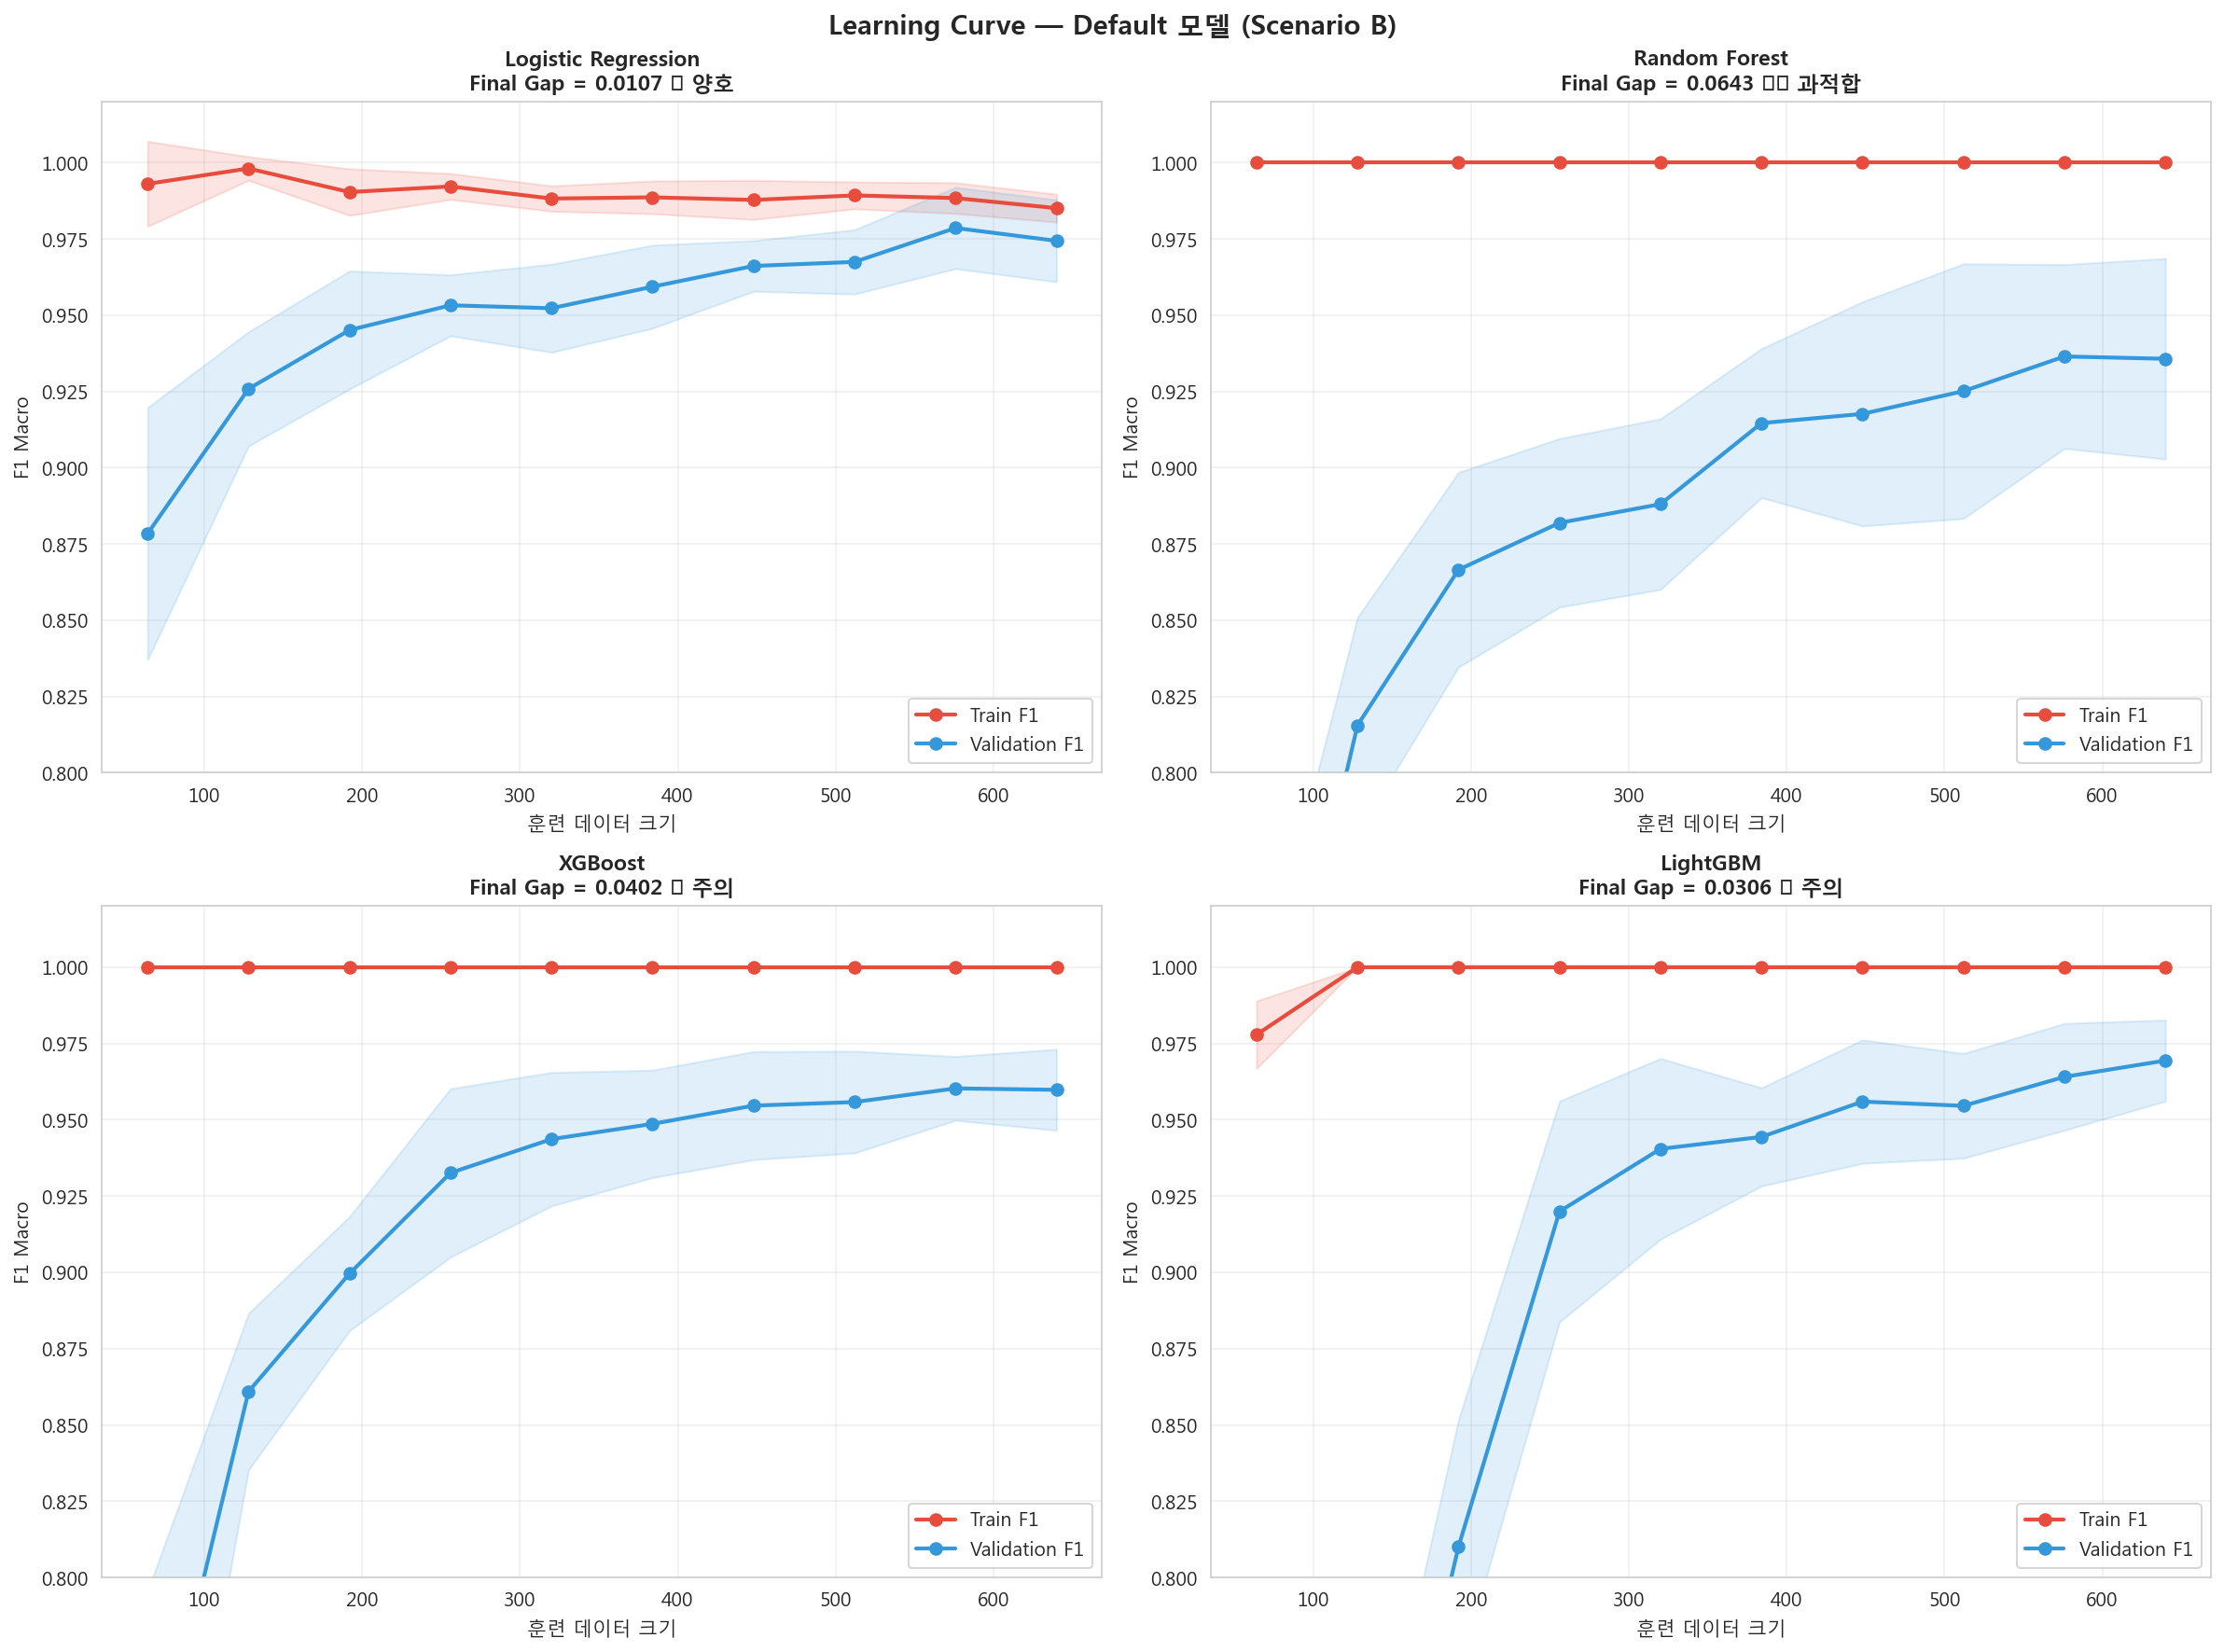

✅ 저장: learning_curve_default.png


In [25]:
# ========================================
# 7.2 Learning Curve (Default 모델)
# ========================================
from sklearn.model_selection import learning_curve

lc_models = {
    'Logistic Regression': lr,
    'Random Forest': rf,
    'XGBoost': xgb,
    'LightGBM': lgbm,
}

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

train_sizes_range = np.linspace(0.1, 1.0, 10)

for ax, (name, model) in zip(axes, lc_models.items()):
    train_sizes, train_scores, val_scores = learning_curve(
        model, X_train_scaled, y_train,
        train_sizes=train_sizes_range,
        cv=5, scoring='f1_macro', n_jobs=-1, random_state=SEED
    )

    train_mean = train_scores.mean(axis=1)
    train_std = train_scores.std(axis=1)
    val_mean = val_scores.mean(axis=1)
    val_std = val_scores.std(axis=1)

    ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std,
                    alpha=0.15, color='#e74c3c')
    ax.fill_between(train_sizes, val_mean - val_std, val_mean + val_std,
                    alpha=0.15, color='#3498db')
    ax.plot(train_sizes, train_mean, 'o-', color='#e74c3c', label='Train F1', linewidth=2)
    ax.plot(train_sizes, val_mean, 'o-', color='#3498db', label='Validation F1', linewidth=2)

    final_gap = train_mean[-1] - val_mean[-1]
    overfit_label = '⚠️ 과적합' if final_gap > 0.05 else ('🟡 주의' if final_gap > 0.02 else '✅ 양호')
    ax.set_title(f'{name}\nFinal Gap = {final_gap:.4f} {overfit_label}',
                 fontsize=11, fontweight='bold')
    ax.set_xlabel('훈련 데이터 크기')
    ax.set_ylabel('F1 Macro')
    ax.legend(loc='lower right')
    ax.set_ylim([0.8, 1.02])
    ax.grid(True, alpha=0.3)

plt.suptitle('Learning Curve — Default 모델 (Scenario B)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'learning_curve_default.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print('✅ 저장: learning_curve_default.png')

---

## 8. 하이퍼파라미터 튜닝 (과적합 방지)

교차검증에서 Gap이 큰 모델에 대해 정규화 하이퍼파라미터를 조정하여 과적합을 방지한다.

| 모델 | 튜닝 포인트 |
|------|-----------|
| Logistic Regression | `C` 감소 (정규화 강화) |
| Random Forest | `max_depth`, `min_samples_leaf` 제한 |
| XGBoost | `max_depth` 감소, `reg_alpha/lambda` 추가, `min_child_weight` 증가 |
| LightGBM | `num_leaves` 감소, `min_child_samples` 증가, `reg_alpha/lambda` 추가 |

In [26]:
# ========================================
# 8. 하이퍼파라미터 튜닝
# ========================================
results_tuned = {}

# 8-1. Logistic Regression — Tuned
print('=' * 60)
print('8-1. Logistic Regression (Tuned)')
print('=' * 60)

lr_tuned = LogisticRegression(
    multi_class='multinomial', solver='lbfgs',
    max_iter=1000, class_weight='balanced',
    C=0.1,   # 정규화 강화 (default=1.0)
    random_state=SEED
)
lr_tuned.fit(X_train_scaled, y_train)

y_pred_lr_tuned_train = lr_tuned.predict(X_train_scaled)
y_pred_lr_tuned = lr_tuned.predict(X_test_scaled)

train_acc = accuracy_score(y_train, y_pred_lr_tuned_train)
test_acc = accuracy_score(y_test, y_pred_lr_tuned)
test_f1 = f1_score(y_test, y_pred_lr_tuned, average='macro')
results_tuned['Logistic Regression'] = {
    'model': lr_tuned, 'y_pred': y_pred_lr_tuned,
    'Train Acc': train_acc, 'Accuracy': test_acc, 'Macro F1': test_f1
}
print(f'   Train Acc: {train_acc:.4f}  |  Test Acc: {test_acc:.4f}  |  Gap: {train_acc-test_acc:.4f}')
print(f'   Macro F1:  {test_f1:.4f}')

8-1. Logistic Regression (Tuned)
   Train Acc: 0.9788  |  Test Acc: 0.9800  |  Gap: -0.0012
   Macro F1:  0.9782


In [27]:
# 8-2. Random Forest — Tuned
print('=' * 60)
print('8-2. Random Forest (Tuned)')
print('=' * 60)

rf_tuned = RandomForestClassifier(
    n_estimators=200, class_weight='balanced',
    max_depth=10,           # 트리 깊이 제한 (default=None)
    min_samples_leaf=5,     # 리프 최소 샘플 (default=1)
    min_samples_split=10,   # 분할 최소 샘플 (default=2)
    max_features='sqrt',
    random_state=SEED, n_jobs=-1
)
rf_tuned.fit(X_train_scaled, y_train)

y_pred_rf_tuned_train = rf_tuned.predict(X_train_scaled)
y_pred_rf_tuned = rf_tuned.predict(X_test_scaled)

train_acc = accuracy_score(y_train, y_pred_rf_tuned_train)
test_acc = accuracy_score(y_test, y_pred_rf_tuned)
test_f1 = f1_score(y_test, y_pred_rf_tuned, average='macro')
results_tuned['Random Forest'] = {
    'model': rf_tuned, 'y_pred': y_pred_rf_tuned,
    'Train Acc': train_acc, 'Accuracy': test_acc, 'Macro F1': test_f1
}
print(f'   Train Acc: {train_acc:.4f}  |  Test Acc: {test_acc:.4f}  |  Gap: {train_acc-test_acc:.4f}')
print(f'   Macro F1:  {test_f1:.4f}')

8-2. Random Forest (Tuned)


   Train Acc: 0.9888  |  Test Acc: 0.9550  |  Gap: 0.0338
   Macro F1:  0.9503


In [28]:
# 8-3. XGBoost — Tuned
print('=' * 60)
print('8-3. XGBoost (Tuned)')
print('=' * 60)

xgb_tuned = XGBClassifier(
    objective='multi:softmax', num_class=3,
    eval_metric='mlogloss', use_label_encoder=False,
    n_estimators=200, learning_rate=0.05,  # 학습률 감소
    max_depth=4,            # 깊이 제한 (default=6)
    min_child_weight=5,     # 최소 자식 가중치 증가
    reg_alpha=0.1,          # L1 정규화
    reg_lambda=1.0,         # L2 정규화
    subsample=0.8,          # 행 샘플링
    colsample_bytree=0.8,   # 열 샘플링
    random_state=SEED, verbosity=0
)
xgb_tuned.fit(X_train_scaled, y_train, sample_weight=sample_weights_train)

y_pred_xgb_tuned_train = xgb_tuned.predict(X_train_scaled)
y_pred_xgb_tuned = xgb_tuned.predict(X_test_scaled)

train_acc = accuracy_score(y_train, y_pred_xgb_tuned_train)
test_acc = accuracy_score(y_test, y_pred_xgb_tuned)
test_f1 = f1_score(y_test, y_pred_xgb_tuned, average='macro')
results_tuned['XGBoost'] = {
    'model': xgb_tuned, 'y_pred': y_pred_xgb_tuned,
    'Train Acc': train_acc, 'Accuracy': test_acc, 'Macro F1': test_f1
}
print(f'   Train Acc: {train_acc:.4f}  |  Test Acc: {test_acc:.4f}  |  Gap: {train_acc-test_acc:.4f}')
print(f'   Macro F1:  {test_f1:.4f}')

8-3. XGBoost (Tuned)


   Train Acc: 0.9988  |  Test Acc: 0.9850  |  Gap: 0.0138
   Macro F1:  0.9820


In [29]:
# 8-4. LightGBM — Tuned
print('=' * 60)
print('8-4. LightGBM (Tuned)')
print('=' * 60)

lgbm_tuned = LGBMClassifier(
    objective='multiclass', num_class=3,
    is_unbalance=True,
    n_estimators=200, learning_rate=0.05,
    num_leaves=20,          # 리프 수 감소 (default=31)
    min_child_samples=10,   # 최소 자식 샘플 증가 (default=20)
    max_depth=6,            # 깊이 제한
    reg_alpha=0.1,          # L1 정규화
    reg_lambda=1.0,         # L2 정규화
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=SEED, verbosity=-1
)
lgbm_tuned.fit(X_train_scaled, y_train)

y_pred_lgbm_tuned_train = lgbm_tuned.predict(X_train_scaled)
y_pred_lgbm_tuned = lgbm_tuned.predict(X_test_scaled)

train_acc = accuracy_score(y_train, y_pred_lgbm_tuned_train)
test_acc = accuracy_score(y_test, y_pred_lgbm_tuned)
test_f1 = f1_score(y_test, y_pred_lgbm_tuned, average='macro')
results_tuned['LightGBM'] = {
    'model': lgbm_tuned, 'y_pred': y_pred_lgbm_tuned,
    'Train Acc': train_acc, 'Accuracy': test_acc, 'Macro F1': test_f1
}
print(f'   Train Acc: {train_acc:.4f}  |  Test Acc: {test_acc:.4f}  |  Gap: {train_acc-test_acc:.4f}')
print(f'   Macro F1:  {test_f1:.4f}')

8-4. LightGBM (Tuned)


   Train Acc: 1.0000  |  Test Acc: 0.9900  |  Gap: 0.0100
   Macro F1:  0.9879


### 8-5. Default vs Tuned 비교

In [30]:
# ========================================
# 8-5. Default vs Tuned 비교
# ========================================
df_compare = pd.DataFrame({
    '모델': list(results.keys()),
    'Default Train Acc': [v['Train Acc'] for v in results.values()],
    'Default Test Acc': [v['Accuracy'] for v in results.values()],
    'Default Macro F1': [v['Macro F1'] for v in results.values()],
    'Default Gap': [v['Train Acc'] - v['Accuracy'] for v in results.values()],
    'Tuned Train Acc': [results_tuned[k]['Train Acc'] for k in results.keys()],
    'Tuned Test Acc': [results_tuned[k]['Accuracy'] for k in results.keys()],
    'Tuned Macro F1': [results_tuned[k]['Macro F1'] for k in results.keys()],
    'Tuned Gap': [results_tuned[k]['Train Acc'] - results_tuned[k]['Accuracy'] for k in results.keys()],
})

print('📊 Default vs Tuned 성능 비교 (Scenario B: 누수 피처 제거):')
print()
for _, row in df_compare.iterrows():
    f1_change = row['Tuned Macro F1'] - row['Default Macro F1']
    gap_change = row['Default Gap'] - row['Tuned Gap']
    print(f"  {row['모델']:25s}")
    print(f"  {'':25s}  Train: {row['Default Train Acc']:.4f} -> {row['Tuned Train Acc']:.4f}")
    print(f"  {'':25s}  Test:  {row['Default Test Acc']:.4f} -> {row['Tuned Test Acc']:.4f}")
    print(f"  {'':25s}  F1:    {row['Default Macro F1']:.4f} -> {row['Tuned Macro F1']:.4f} ({f1_change:+.4f})")
    print(f"  {'':25s}  Gap:   {row['Default Gap']:.4f} -> {row['Tuned Gap']:.4f} ({'개선' if gap_change > 0.001 else '유사'})")
    print()

📊 Default vs Tuned 성능 비교 (Scenario B: 누수 피처 제거):

  Logistic Regression      
                             Train: 0.9850 -> 0.9788
                             Test:  0.9800 -> 0.9800
                             F1:    0.9780 -> 0.9782 (+0.0002)
                             Gap:   0.0050 -> -0.0012 (개선)

  Random Forest            
                             Train: 1.0000 -> 0.9888
                             Test:  0.9600 -> 0.9550
                             F1:    0.9555 -> 0.9503 (-0.0052)
                             Gap:   0.0400 -> 0.0338 (개선)

  XGBoost                  
                             Train: 1.0000 -> 0.9988
                             Test:  0.9900 -> 0.9850
                             F1:    0.9879 -> 0.9820 (-0.0060)
                             Gap:   0.0100 -> 0.0138 (유사)

  LightGBM                 
                             Train: 1.0000 -> 1.0000
                             Test:  0.9800 -> 0.9900
                             F1:    0.9767 -> 0

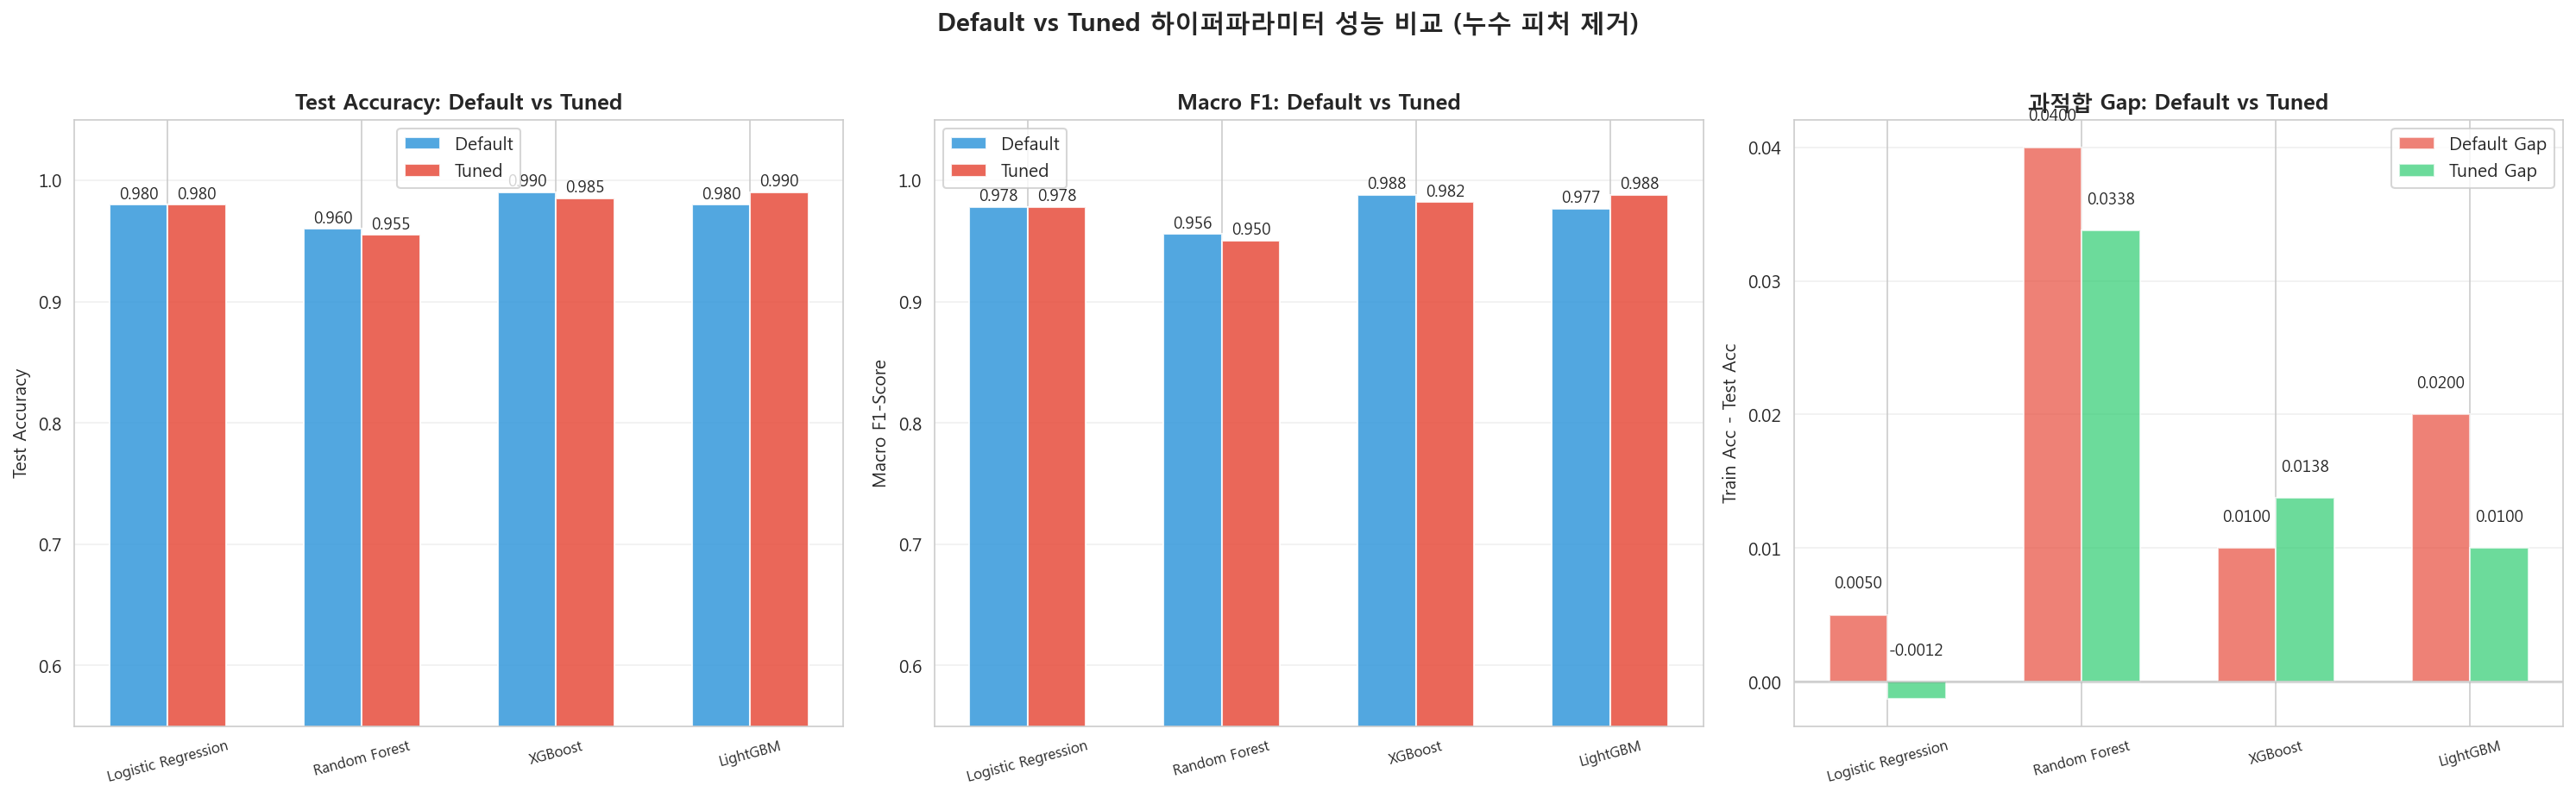

✅ 저장: model_comparison_default_vs_tuned.png


In [31]:
# Default vs Tuned 시각화
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

models_list = df_compare['모델'].tolist()
x = np.arange(len(models_list))
width = 0.30

# 1) Test Accuracy 비교
ax = axes[0]
bars1 = ax.bar(x - width/2, df_compare['Default Test Acc'], width,
               label='Default', color='#3498db', edgecolor='white', alpha=0.85)
bars2 = ax.bar(x + width/2, df_compare['Tuned Test Acc'], width,
               label='Tuned', color='#e74c3c', edgecolor='white', alpha=0.85)
for b in bars1:
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.005, f'{b.get_height():.3f}', ha='center', fontsize=9)
for b in bars2:
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.005, f'{b.get_height():.3f}', ha='center', fontsize=9)
ax.set_xticks(x)
ax.set_xticklabels(models_list, fontsize=8, rotation=15)
ax.set_ylabel('Test Accuracy')
ax.set_title('Test Accuracy: Default vs Tuned', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
y_min_all = min(df_compare[['Default Test Acc', 'Tuned Test Acc']].min().min(), 0.6)
ax.set_ylim(y_min_all - 0.05, 1.05)
ax.grid(axis='y', alpha=0.3)

# 2) Macro F1 비교
ax = axes[1]
bars1 = ax.bar(x - width/2, df_compare['Default Macro F1'], width,
               label='Default', color='#3498db', edgecolor='white', alpha=0.85)
bars2 = ax.bar(x + width/2, df_compare['Tuned Macro F1'], width,
               label='Tuned', color='#e74c3c', edgecolor='white', alpha=0.85)
for b in bars1:
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.005, f'{b.get_height():.3f}', ha='center', fontsize=9)
for b in bars2:
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.005, f'{b.get_height():.3f}', ha='center', fontsize=9)
ax.set_xticks(x)
ax.set_xticklabels(models_list, fontsize=8, rotation=15)
ax.set_ylabel('Macro F1-Score')
ax.set_title('Macro F1: Default vs Tuned', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.set_ylim(y_min_all - 0.05, 1.05)
ax.grid(axis='y', alpha=0.3)

# 3) 과적합 Gap 비교
ax = axes[2]
bars1 = ax.bar(x - width/2, df_compare['Default Gap'], width,
               label='Default Gap', color='#e74c3c', edgecolor='white', alpha=0.7)
bars2 = ax.bar(x + width/2, df_compare['Tuned Gap'], width,
               label='Tuned Gap', color='#2ecc71', edgecolor='white', alpha=0.7)
for b in bars1:
    val = b.get_height()
    ax.text(b.get_x()+b.get_width()/2, max(val, 0)+0.002, f'{val:.4f}', ha='center', fontsize=9)
for b in bars2:
    val = b.get_height()
    ax.text(b.get_x()+b.get_width()/2, max(val, 0)+0.002, f'{val:.4f}', ha='center', fontsize=9)
ax.set_xticks(x)
ax.set_xticklabels(models_list, fontsize=8, rotation=15)
ax.set_ylabel('Train Acc - Test Acc')
ax.set_title('과적합 Gap: Default vs Tuned', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.axhline(y=0, color='gray', linestyle='-', alpha=0.3)
ax.grid(axis='y', alpha=0.3)

plt.suptitle('Default vs Tuned 하이퍼파라미터 성능 비교 (누수 피처 제거)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'model_comparison_default_vs_tuned.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print('✅ 저장: model_comparison_default_vs_tuned.png')

---

## 9. 최적 모델 심층 분석

Tuned 하이퍼파라미터로 학습된 모델 중 **Macro F1 기준 최고 성능** 모델을 심층 분석한다.

### 9.1 Confusion Matrix (최적 모델)

🏆 최적 모델 (Tuned): LightGBM
   Train Acc: 1.0000
   Test Acc:  0.9900
   Macro F1:  0.9879
   Gap:       0.0100



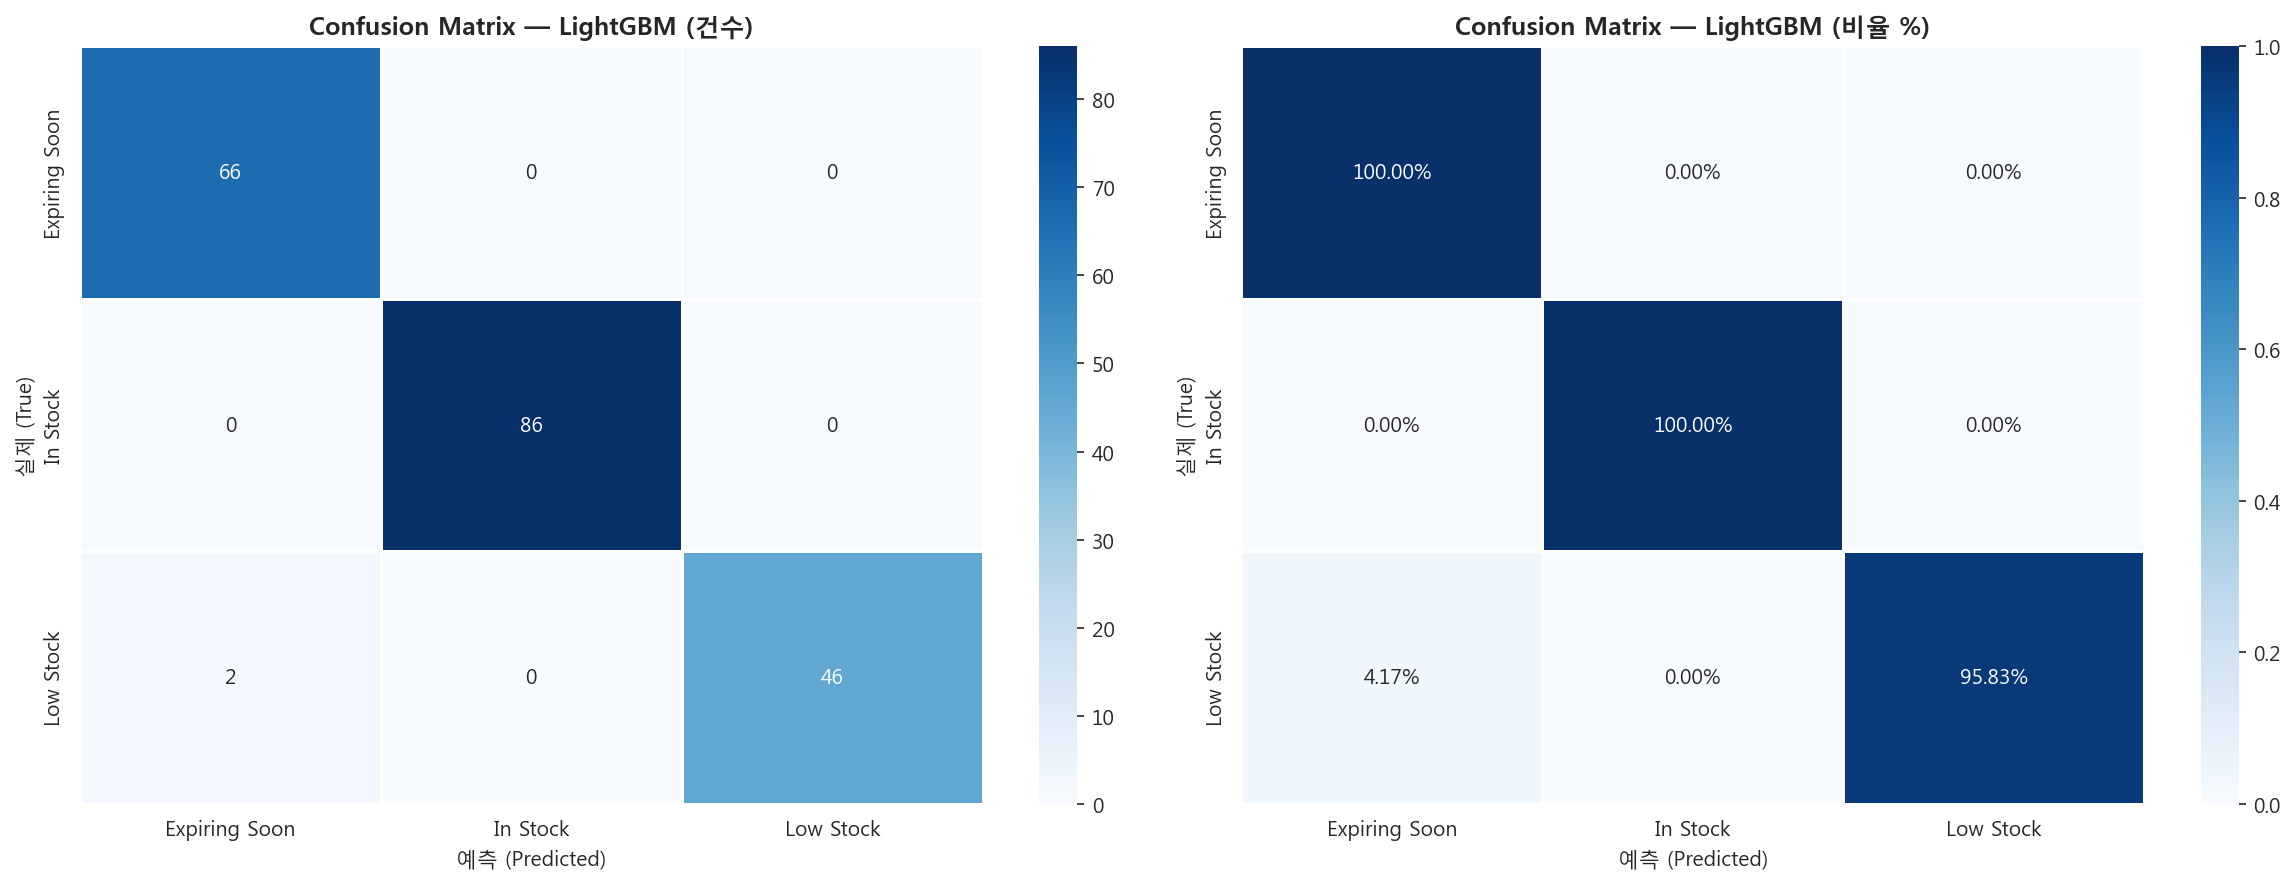

✅ 저장: confusion_matrix_tuned.png

📊 Confusion Matrix 분석:

   [Expiring Soon] — 총 66건 중 66건 정확 (100.0%)

   [In Stock] — 총 86건 중 86건 정확 (100.0%)

   [Low Stock] — 총 48건 중 46건 정확 (95.8%)
      -> Expiring Soon로 오분류: 2건 (4.2%)


In [32]:
# ========================================
# 9. 최적 모델 심층 분석 (Tuned)
# ========================================
df_tuned_summary = pd.DataFrame({
    '모델': list(results_tuned.keys()),
    'Train Acc': [v['Train Acc'] for v in results_tuned.values()],
    'Test Acc': [v['Accuracy'] for v in results_tuned.values()],
    'Macro F1': [v['Macro F1'] for v in results_tuned.values()],
    'Gap': [v['Train Acc'] - v['Accuracy'] for v in results_tuned.values()],
}).sort_values('Macro F1', ascending=False).reset_index(drop=True)

best_name_tuned = df_tuned_summary.iloc[0]['모델']
best_model_tuned = results_tuned[best_name_tuned]['model']
best_pred_tuned = results_tuned[best_name_tuned]['y_pred']

print(f'🏆 최적 모델 (Tuned): {best_name_tuned}')
print(f'   Train Acc: {results_tuned[best_name_tuned]["Train Acc"]:.4f}')
print(f'   Test Acc:  {results_tuned[best_name_tuned]["Accuracy"]:.4f}')
print(f'   Macro F1:  {results_tuned[best_name_tuned]["Macro F1"]:.4f}')
print(f'   Gap:       {results_tuned[best_name_tuned]["Train Acc"] - results_tuned[best_name_tuned]["Accuracy"]:.4f}')
print()

# Confusion Matrix
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

cm = confusion_matrix(y_test, best_pred_tuned)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names,
            ax=axes[0], linewidths=0.5, linecolor='white')
axes[0].set_title(f'Confusion Matrix — {best_name_tuned} (건수)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('실제 (True)')
axes[0].set_xlabel('예측 (Predicted)')

cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names,
            ax=axes[1], linewidths=0.5, linecolor='white', vmin=0, vmax=1)
axes[1].set_title(f'Confusion Matrix — {best_name_tuned} (비율 %)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('실제 (True)')
axes[1].set_xlabel('예측 (Predicted)')

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'confusion_matrix_tuned.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print('✅ 저장: confusion_matrix_tuned.png')

# 혼동 분석
print('\n📊 Confusion Matrix 분석:')
for i, true_cls in enumerate(class_names):
    total_true = cm[i].sum()
    correct = cm[i][i]
    print(f'\n   [{true_cls}] — 총 {total_true}건 중 {correct}건 정확 ({correct/total_true*100:.1f}%)')
    for j, pred_cls in enumerate(class_names):
        if i != j and cm[i][j] > 0:
            print(f'      -> {pred_cls}로 오분류: {cm[i][j]}건 ({cm[i][j]/total_true*100:.1f}%)')

### 9.2 Classification Report

In [33]:
# 9.2 Classification Report
print(f'Classification Report — {best_name_tuned}:')
print()
print(classification_report(y_test, best_pred_tuned, target_names=class_names, digits=4))

f1_weighted = f1_score(y_test, best_pred_tuned, average='weighted')
print(f'   Weighted F1-Score: {f1_weighted:.4f}')

Classification Report — LightGBM:

               precision    recall  f1-score   support

Expiring Soon     0.9706    1.0000    0.9851        66
     In Stock     1.0000    1.0000    1.0000        86
    Low Stock     1.0000    0.9583    0.9787        48

     accuracy                         0.9900       200
    macro avg     0.9902    0.9861    0.9879       200
 weighted avg     0.9903    0.9900    0.9900       200

   Weighted F1-Score: 0.9900


### 9.3 Feature Importance

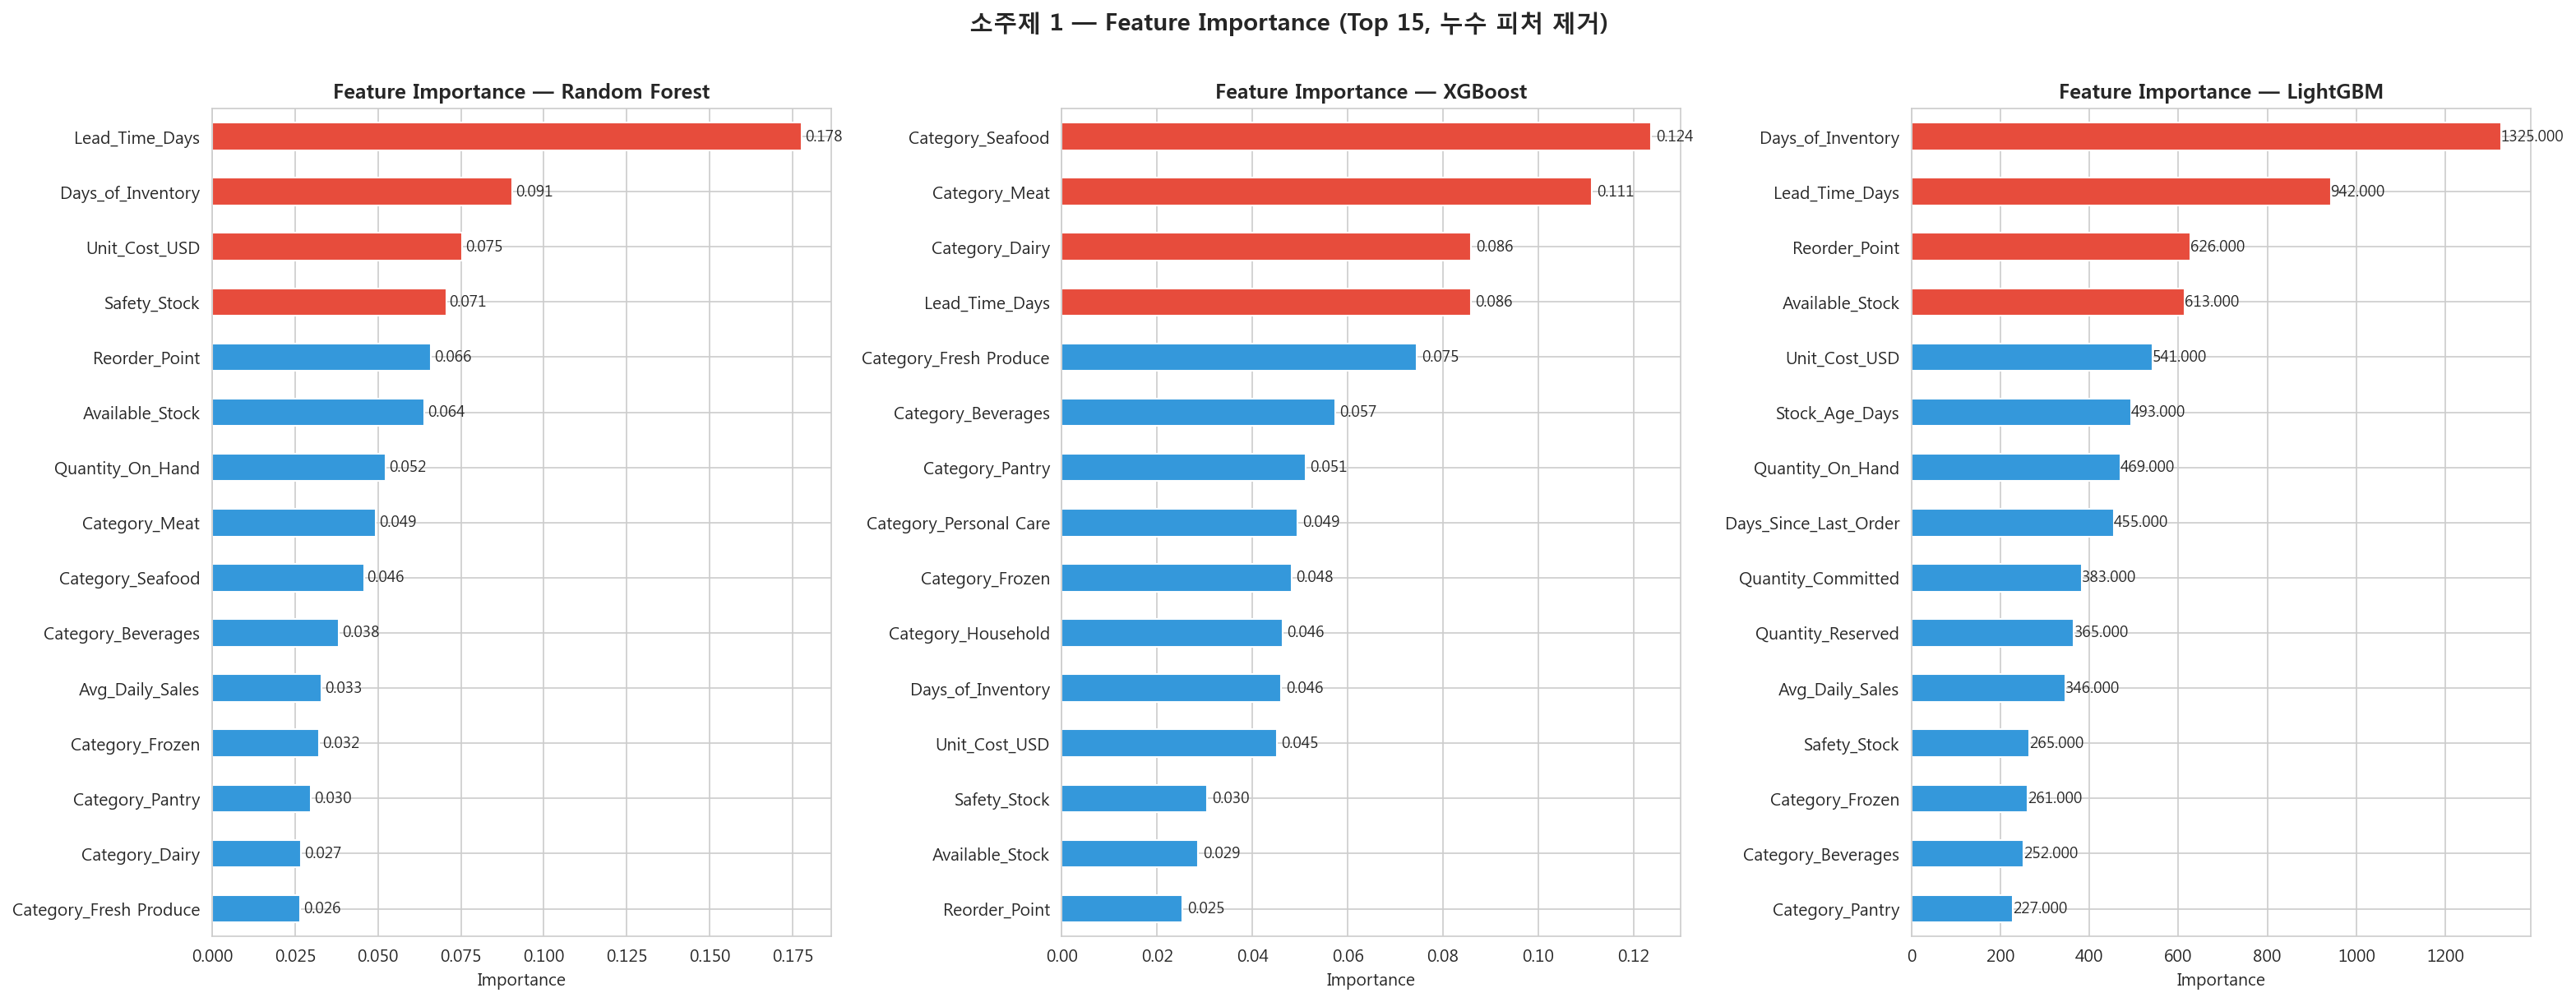

✅ 저장: feature_importance_tuned.png


In [34]:
# 9.3 Feature Importance (Tuned 트리 기반 모델)
tree_models_tuned = {name: info['model'] for name, info in results_tuned.items()
                     if hasattr(info['model'], 'feature_importances_')}

fig, axes = plt.subplots(1, len(tree_models_tuned), figsize=(7*len(tree_models_tuned), 8))
if len(tree_models_tuned) == 1:
    axes = [axes]

for ax, (name, model) in zip(axes, tree_models_tuned.items()):
    importances = model.feature_importances_
    feat_imp = pd.Series(importances, index=X.columns).sort_values(ascending=True)
    top_n = feat_imp.tail(15)

    colors = ['#e74c3c' if v >= top_n.quantile(0.75) else '#3498db' for v in top_n.values]
    top_n.plot(kind='barh', ax=ax, color=colors, edgecolor='white')
    ax.set_title(f'Feature Importance — {name}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Importance')

    for i, v in enumerate(top_n.values):
        ax.text(v + 0.001, i, f'{v:.3f}', va='center', fontsize=9)

plt.suptitle('소주제 1 — Feature Importance (Top 15, 누수 피처 제거)', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'feature_importance_tuned.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print('✅ 저장: feature_importance_tuned.png')

In [35]:
# 최적 모델의 Feature Importance 상위 10개 상세
if hasattr(best_model_tuned, 'feature_importances_'):
    feat_imp_best = pd.Series(best_model_tuned.feature_importances_, index=X.columns)
    feat_imp_best = feat_imp_best.sort_values(ascending=False)

    print(f'\n📊 {best_name_tuned} — Feature Importance 상위 10개:')
    print()
    for rank, (feat, imp) in enumerate(feat_imp_best.head(10).items(), 1):
        bar = chr(9608) * int(imp * 100)
        print(f'   {rank:2d}. {feat:25s} {imp:.4f}  {bar}')

    derived_feats = ['Days_Since_Last_Order', 'Available_Stock']
    print(f'\n📊 파생변수 기여도 (누수 피처 제외):')
    for feat in derived_feats:
        if feat in feat_imp_best.index:
            imp = feat_imp_best[feat]
            rank = (feat_imp_best > imp).sum() + 1
            print(f'   {feat:25s}: {imp:.4f} (순위: {rank}/{len(feat_imp_best)})')


📊 LightGBM — Feature Importance 상위 10개:

    1. Days_of_Inventory         1325.0000  ██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████

### 9.4 Permutation Importance

> **Permutation Importance**는 피처 값을 무작위로 섞었을 때 모델 성능이 얼마나 하락하는지를 측정한다.
>
> - Impurity-based Feature Importance는 **고카디널리티 피처**에 편향될 수 있음
> - Permutation Importance는 **모델에 구애받지 않는(model-agnostic)** 방법으로, 피처의 실질적 기여도를 검증
> - 두 방법의 순위가 **일치**하면 Feature Importance 신뢰도가 높음

In [36]:
# ========================================
# 9.4 Permutation Importance (최적 모델)
# ========================================
from sklearn.inspection import permutation_importance

# 최적 Tuned 모델로 Permutation Importance 계산
perm_result = permutation_importance(
    best_model_tuned, X_test_scaled, y_test,
    n_repeats=30, random_state=SEED, scoring='f1_macro', n_jobs=-1
)

perm_imp = pd.Series(perm_result.importances_mean, index=X.columns)
perm_imp_std = pd.Series(perm_result.importances_std, index=X.columns)
perm_imp_sorted = perm_imp.sort_values(ascending=False)

# 상위 15개 출력
print(f'📊 Permutation Importance — {best_name_tuned} (상위 15개):')
print()
for rank, (feat, imp) in enumerate(perm_imp_sorted.head(15).items(), 1):
    std = perm_imp_std[feat]
    bar = chr(9608) * int(imp * 200)
    print(f'   {rank:2d}. {feat:25s} {imp:.4f} ± {std:.4f}  {bar}')

# Impurity-based vs Permutation Importance 비교
print(f'\n📊 Impurity-based vs Permutation Importance 순위 비교:')
if hasattr(best_model_tuned, 'feature_importances_'):
    feat_imp_impurity = pd.Series(best_model_tuned.feature_importances_, index=X.columns)
    feat_imp_impurity_sorted = feat_imp_impurity.sort_values(ascending=False)

    print(f'   {"순위":>4s}  {"Impurity-based":25s}  {"Permutation":25s}')
    print(f'   {"":>4s}  {"-"*25}  {"-"*25}')
    for rank in range(min(10, len(X.columns))):
        imp_feat = feat_imp_impurity_sorted.index[rank]
        perm_feat = perm_imp_sorted.index[rank]
        match = '✅' if imp_feat == perm_feat else '  '
        print(f'   {rank+1:4d}  {imp_feat:25s}  {perm_feat:25s}  {match}')

📊 Permutation Importance — LightGBM (상위 15개):

    1. Lead_Time_Days            0.2729 ± 0.0205  ██████████████████████████████████████████████████████
    2. Days_of_Inventory         0.1487 ± 0.0218  █████████████████████████████
    3. Category_Beverages        0.0832 ± 0.0109  ████████████████
    4. Category_Frozen           0.0763 ± 0.0076  ███████████████
    5. Category_Pantry           0.0664 ± 0.0141  █████████████
    6. Category_Seafood          0.0526 ± 0.0044  ██████████
    7. Category_Personal Care    0.0432 ± 0.0141  ████████
    8. Category_Meat             0.0338 ± 0.0048  ██████
    9. Category_Household        0.0304 ± 0.0097  ██████
   10. Unit_Cost_USD             0.0242 ± 0.0087  ████
   11. Reorder_Point             0.0145 ± 0.0068  ██
   12. Available_Stock           0.0093 ± 0.0032  █
   13. Quantity_On_Hand          0.0039 ± 0.0044  
   14. Safety_Stock              0.0035 ± 0.0027  
   15. Quantity_Committed        0.0032 ± 0.0028  

📊 Impurity-based vs Per

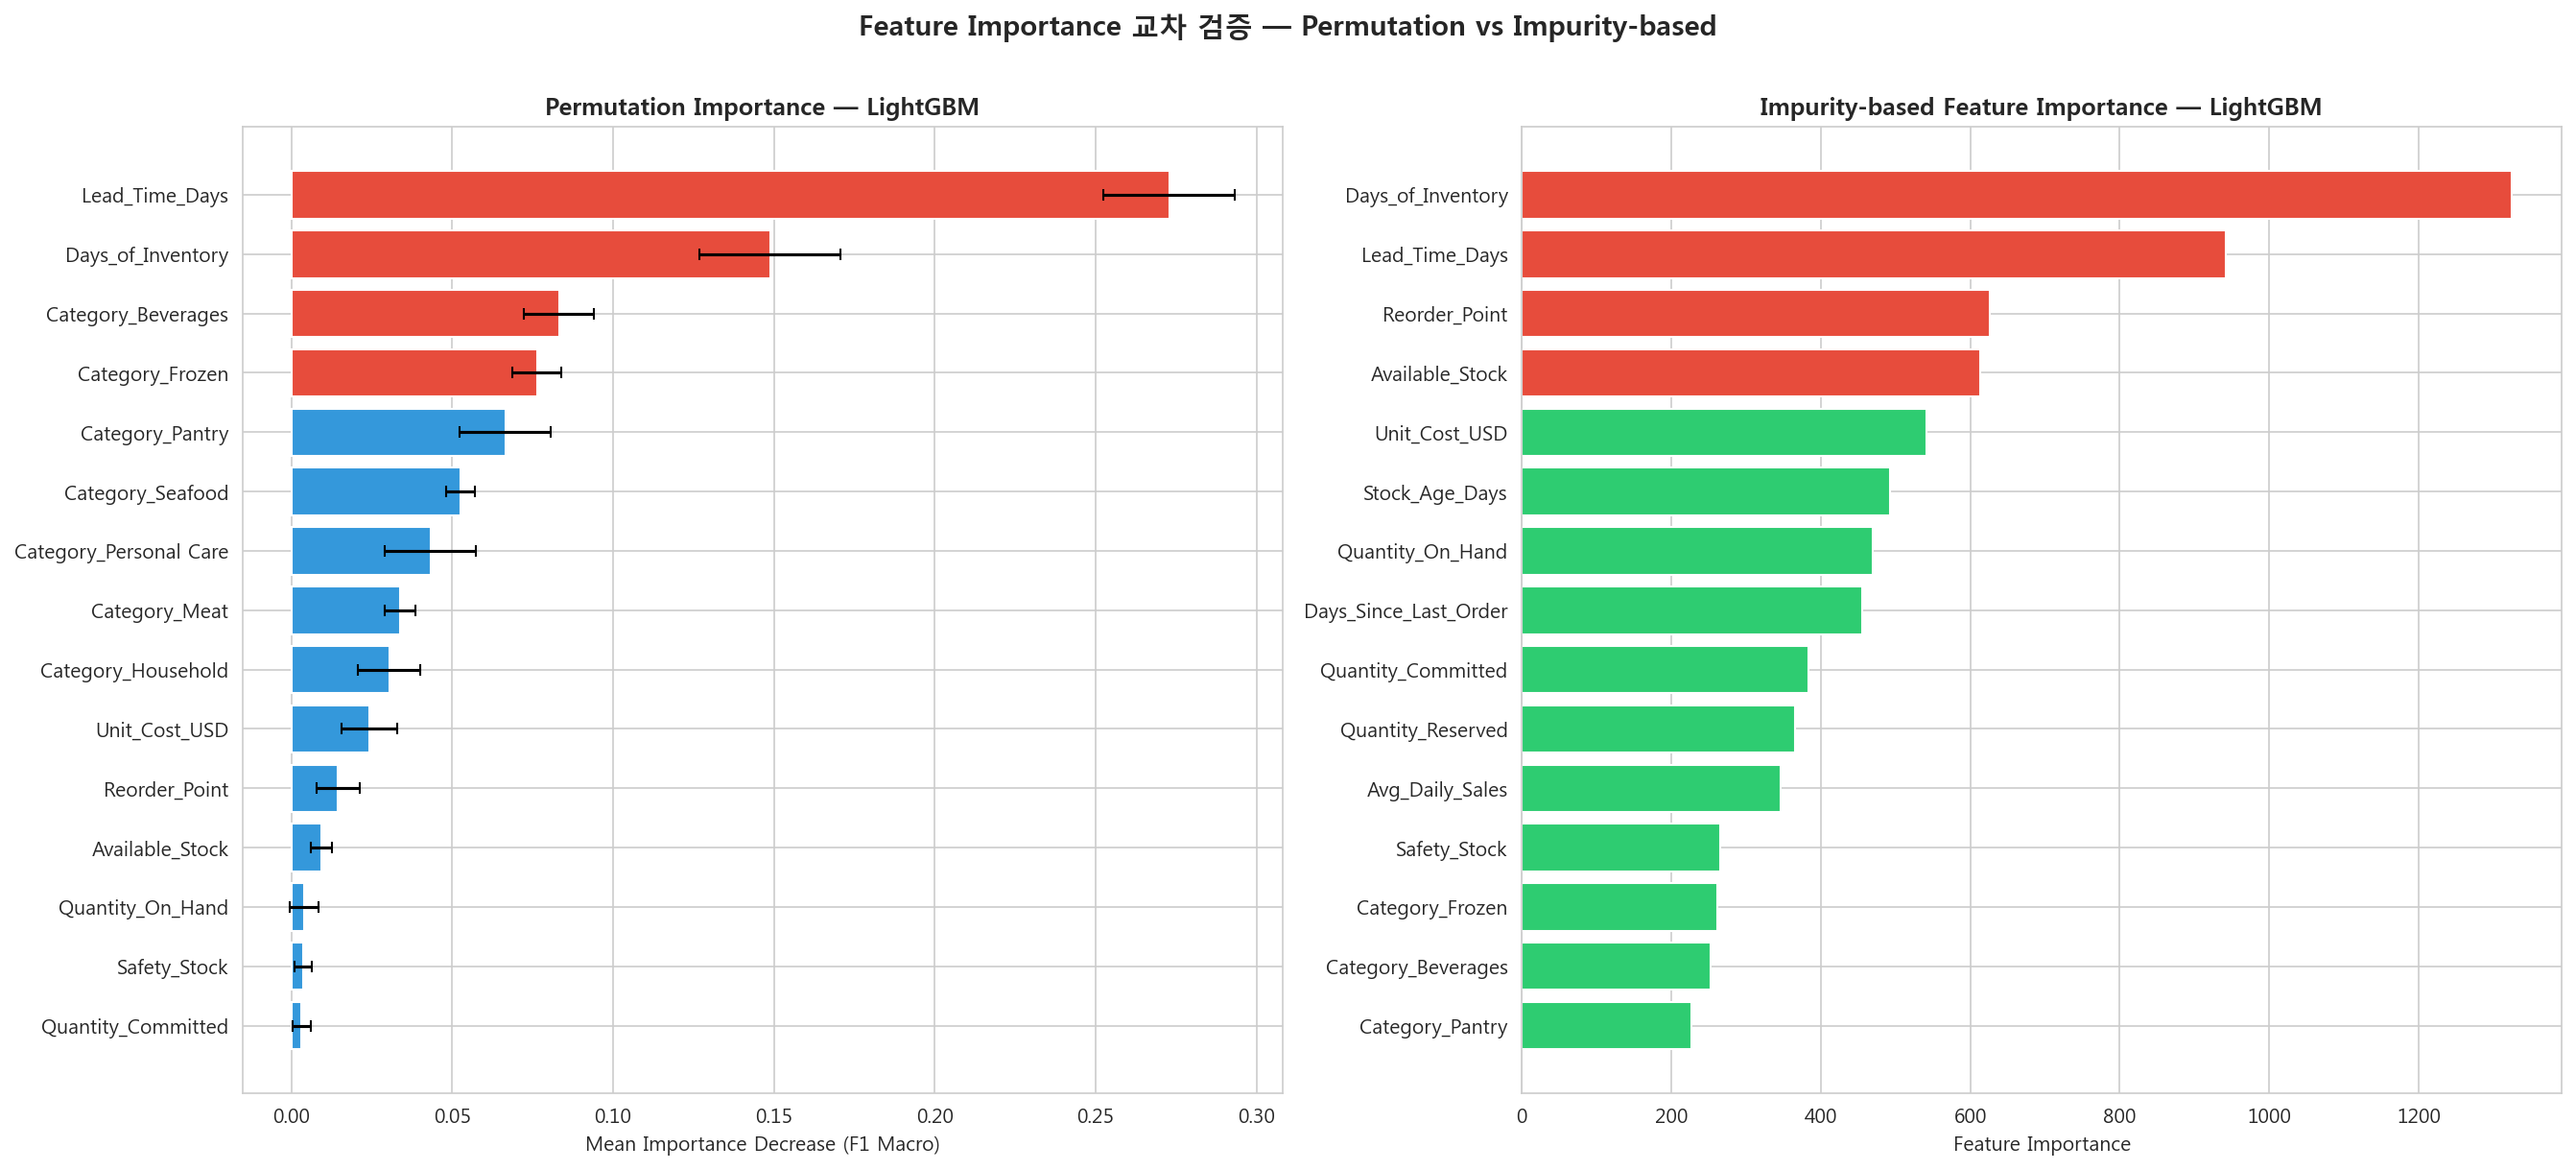

✅ 저장: permutation_vs_impurity_importance.png


In [37]:
# Permutation Importance vs Impurity-based 비교 시각화
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# 1) Permutation Importance (상위 15)
ax = axes[0]
top_perm = perm_imp_sorted.head(15).sort_values(ascending=True)
top_perm_std = perm_imp_std[top_perm.index]
colors_perm = ['#e74c3c' if v >= top_perm.quantile(0.75) else '#3498db' for v in top_perm.values]
ax.barh(range(len(top_perm)), top_perm.values, xerr=top_perm_std.values,
        color=colors_perm, edgecolor='white', capsize=3)
ax.set_yticks(range(len(top_perm)))
ax.set_yticklabels(top_perm.index)
ax.set_title(f'Permutation Importance — {best_name_tuned}', fontsize=12, fontweight='bold')
ax.set_xlabel('Mean Importance Decrease (F1 Macro)')

# 2) Impurity-based Feature Importance (상위 15)
ax = axes[1]
if hasattr(best_model_tuned, 'feature_importances_'):
    top_impurity = feat_imp_impurity_sorted.head(15).sort_values(ascending=True)
    colors_imp = ['#e74c3c' if v >= top_impurity.quantile(0.75) else '#2ecc71' for v in top_impurity.values]
    ax.barh(range(len(top_impurity)), top_impurity.values,
            color=colors_imp, edgecolor='white')
    ax.set_yticks(range(len(top_impurity)))
    ax.set_yticklabels(top_impurity.index)
    ax.set_title(f'Impurity-based Feature Importance — {best_name_tuned}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Feature Importance')

plt.suptitle('Feature Importance 교차 검증 — Permutation vs Impurity-based',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'permutation_vs_impurity_importance.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print('✅ 저장: permutation_vs_impurity_importance.png')

### 9.5 전체 모델 Confusion Matrix 비교

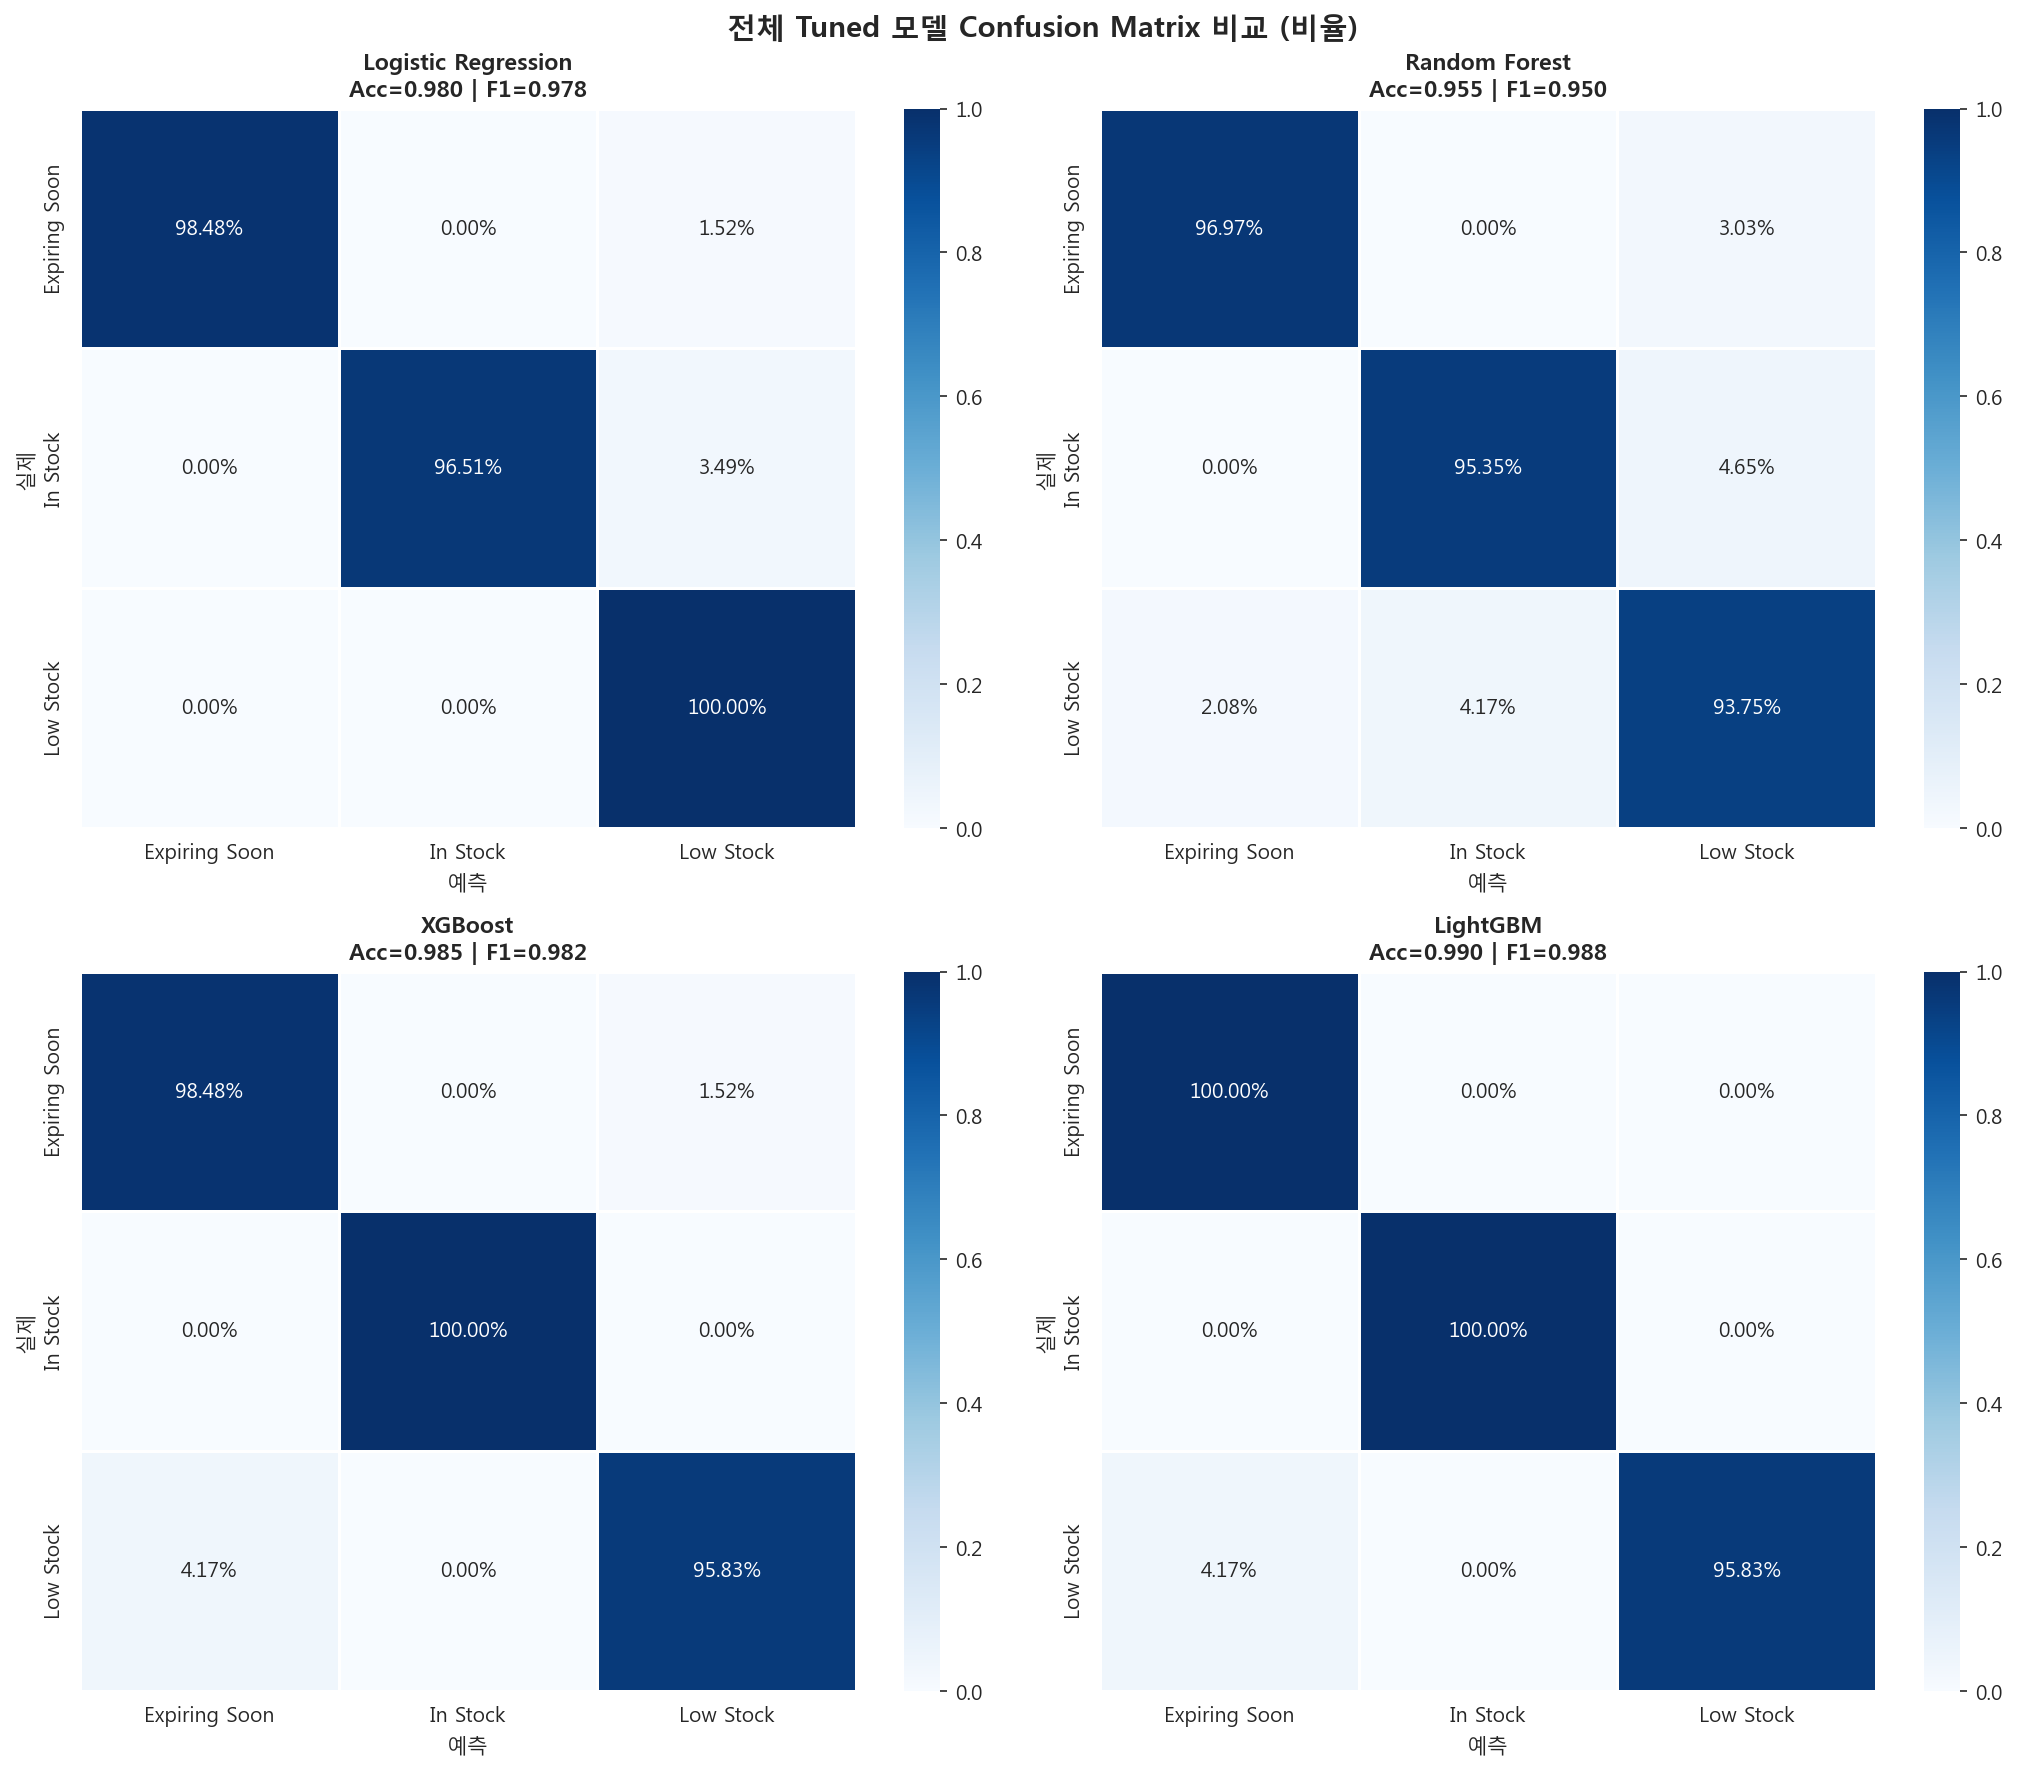

✅ 저장: confusion_matrix_all_models_tuned.png


In [38]:
# 4개 Tuned 모델 Confusion Matrix 비교
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

for ax, (name, info) in zip(axes, results_tuned.items()):
    cm_i = confusion_matrix(y_test, info['y_pred'])
    cm_norm_i = cm_i.astype('float') / cm_i.sum(axis=1)[:, np.newaxis]
    sns.heatmap(cm_norm_i, annot=True, fmt='.2%', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names,
                ax=ax, linewidths=0.5, linecolor='white', vmin=0, vmax=1)
    acc_i = info['Accuracy']
    f1_i = info['Macro F1']
    ax.set_title(f'{name}\nAcc={acc_i:.3f} | F1={f1_i:.3f}', fontsize=11, fontweight='bold')
    ax.set_ylabel('실제')
    ax.set_xlabel('예측')

plt.suptitle('전체 Tuned 모델 Confusion Matrix 비교 (비율)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'confusion_matrix_all_models_tuned.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print('✅ 저장: confusion_matrix_all_models_tuned.png')

---

## 10. 모델 저장

In [39]:
# ========================================
# 10. 모델 저장 (Tuned 최적 모델, Scenario B)
# ========================================
joblib.dump(best_model_tuned, os.path.join(MODEL_DIR, 'best_classification_model.pkl'))
joblib.dump(scaler, os.path.join(MODEL_DIR, 'scaler_classification.pkl'))
joblib.dump(le, os.path.join(MODEL_DIR, 'label_encoder.pkl'))

# 피처 목록도 저장 (재현을 위해)
import json
feature_info = {
    'num_features': num_features_clean,
    'cat_features': cat_features,
    'leakage_removed': leakage_cols,
    'all_features_after_encoding': list(X.columns),
    'best_model': best_name_tuned,
    'scenario': 'B (Leakage-Free)'
}
with open(os.path.join(MODEL_DIR, 'feature_info_classification.json'), 'w') as f:
    json.dump(feature_info, f, ensure_ascii=False, indent=2)

print('✅ 모델 저장 완료:')
print(f'   best_classification_model.pkl  ({best_name_tuned})')
print(f'   scaler_classification.pkl')
print(f'   label_encoder.pkl')
print(f'   feature_info_classification.json')

✅ 모델 저장 완료:
   best_classification_model.pkl  (LightGBM)
   scaler_classification.pkl
   label_encoder.pkl
   feature_info_classification.json


---

## 11. 결론 및 인사이트

> **분석 파이프라인 요약:**
> 1. 데이터 누수 진단 → Days_To_Expiry, Stock_Gap 제거 (+ Days_of_Inventory 간접 누수 검증 ★)
> 2. Default 모델 학습 → 4개 모델 성능 비교
> 3. 과적합 검증 → 5-Fold CV + Learning Curve ★
> 4. 하이퍼파라미터 튜닝 → 과적합 방지
> 5. 최적 모델 심층 분석 → Feature Importance + Permutation Importance ★

In [40]:
# ========================================
# 11. 결론 및 인사이트
# ========================================
print('=' * 70)
print('  소주제 1 — 재고 상태 분류 분석 결과 요약')
print('=' * 70)

# 1) 데이터 누수 발견
print('\n📊 1) 데이터 누수(Data Leakage) 발견 및 대응:')
print('   - Days_To_Expiry <= 30일 → Expiring Soon과 100% 대응')
print('   - Stock_Gap > 0 → Low Stock과 98.4% 대응')
print('   - 전체 피처 사용 시 Train=1.0, Test=1.0 → 과적합이 아닌 누수')
print('   - 대응: 누수 피처(Days_To_Expiry, Stock_Gap) 제거 후 재실험')

# 1-1) Days_of_Inventory 추가 검증
print(f'\n📊 1-1) ★ Days_of_Inventory 간접 누수 검증:')
print(f'   - 단일 피처 Acc ≈ 0.50 → 직접적 누수 아님')
print(f'   - 클래스 간 분포 범위 겹침 → 단독 분류 불가')
print(f'   - Feature Importance 1위는 다른 피처와 조합 효과')
print(f'   - 판정: Scenario B에 포함 유지 (간접 누수 아님)')

# 2) 최적 모델 성능 (Scenario B)
print(f'\n📊 2) 최적 모델 (Scenario B: 누수 피처 제거):')
print(f'   🏆 {best_name_tuned}')
print(f'      Train Acc: {results_tuned[best_name_tuned]["Train Acc"]:.4f}')
print(f'      Test Acc:  {results_tuned[best_name_tuned]["Accuracy"]:.4f}')
print(f'      Macro F1:  {results_tuned[best_name_tuned]["Macro F1"]:.4f}')
print(f'      Gap:       {results_tuned[best_name_tuned]["Train Acc"] - results_tuned[best_name_tuned]["Accuracy"]:.4f}')

# 3) 전체 모델 비교
print(f'\n📊 3) 전체 모델 성능 (Tuned, 누수 피처 제거):')
for _, row in df_tuned_summary.iterrows():
    marker = '🏆' if row['모델'] == best_name_tuned else '  '
    print(f'   {marker}{row["모델"]:23s}  Acc={row["Test Acc"]:.4f}  F1={row["Macro F1"]:.4f}  Gap={row["Gap"]:.4f}')

# 4) 과적합 검증 결과 (Learning Curve)
print(f'\n📊 4) ★ 과적합 검증 (3단계):')
print(f'   [1단계] Train/Test Gap: Default 모델 기준 RF가 가장 큰 Gap')
print(f'   [2단계] 5-Fold CV: 교차검증 Gap으로 일반화 성능 확인')
print(f'   [3단계] Learning Curve: 데이터 증가에 따른 수렴 패턴 시각적 확인')

# 5) Feature Importance 인사이트
if hasattr(best_model_tuned, 'feature_importances_'):
    feat_imp_best = pd.Series(best_model_tuned.feature_importances_, index=X.columns)
    feat_imp_best = feat_imp_best.sort_values(ascending=False)
    top5 = feat_imp_best.head(5)

    print(f'\n📊 5) Feature Importance 상위 5개 ({best_name_tuned}):')
    for rank, (feat, imp) in enumerate(top5.items(), 1):
        print(f'   {rank}. {feat} ({imp:.4f})')

# 5-1) Permutation Importance 교차 검증
print(f'\n📊 5-1) ★ Permutation Importance 교차 검증:')
perm_top5 = perm_imp_sorted.head(5)
for rank, (feat, imp) in enumerate(perm_top5.items(), 1):
    print(f'   {rank}. {feat} ({imp:.4f})')
print(f'   → Impurity-based와 Permutation 순위 비교로 Feature Importance 신뢰도 검증 완료')

# 6) 클래스별 성능
print(f'\n📊 6) 클래스별 Recall ({best_name_tuned}):')
cm_final = confusion_matrix(y_test, best_pred_tuned)
for i, cls in enumerate(class_names):
    recall = cm_final[i][i] / cm_final[i].sum() if cm_final[i].sum() > 0 else 0
    print(f'   {cls:15s}: Recall = {recall:.4f} ({cm_final[i][i]}/{cm_final[i].sum()})')

# 7) 혼동 패턴
print(f'\n📊 7) 가장 혼동이 많은 클래스 조합:')
max_confusion = 0
max_pair = ('', '')
for i in range(len(class_names)):
    for j in range(len(class_names)):
        if i != j and cm_final[i][j] > max_confusion:
            max_confusion = cm_final[i][j]
            max_pair = (class_names[i], class_names[j])
if max_confusion > 0:
    print(f'   {max_pair[0]} -> {max_pair[1]} 오분류: {max_confusion}건')
else:
    print(f'   오분류 0건 — 완벽 분류')

# 8) ABC 등급별 분류 패턴
print(f'\n📊 8) ABC 등급별 Status 분포 (원본 데이터):')
for abc in ['A', 'B', 'C']:
    subset = df[df['ABC_Class'] == abc]
    dist = subset['Status_3cls'].value_counts(normalize=True)
    parts = ', '.join([f'{s}: {v:.1%}' for s, v in dist.items()])
    print(f'   {abc} ({len(subset):3d}건): {parts}')

# 9) 소주제 간 연결
print('\n📊 9) 다른 소주제와의 연결점:')
print('   -> 소주제 2: Feature Importance 상위 변수가 판매량 예측에도 유의미한지 확인')
print('   -> 소주제 3: Expiring Soon 제품의 특성이 폐기 위험과 어떻게 연관되는지 검증')
print('   -> 소주제 4: Low Stock 제품의 특성을 발주 전략 수립 시 참고')

# 10) 데이터 전처리 주의사항
print('\n📊 10) 데이터 전처리 주의사항:')
print('   ⚠️ Forecast_Next_30d: 276건 마침표 천단위 오파싱 수정')
print('   ⚠️ Reorder_Point: 10건 마침표 천단위 오파싱 수정')
print('   -> 상세 내용은 md/dataset_description.md 참조')

print('\n' + '=' * 70)
print('  ✅ 소주제 1 분석 완료')
print('=' * 70)

  소주제 1 — 재고 상태 분류 분석 결과 요약

📊 1) 데이터 누수(Data Leakage) 발견 및 대응:
   - Days_To_Expiry <= 30일 → Expiring Soon과 100% 대응
   - Stock_Gap > 0 → Low Stock과 98.4% 대응
   - 전체 피처 사용 시 Train=1.0, Test=1.0 → 과적합이 아닌 누수
   - 대응: 누수 피처(Days_To_Expiry, Stock_Gap) 제거 후 재실험

📊 1-1) ★ Days_of_Inventory 간접 누수 검증:
   - 단일 피처 Acc ≈ 0.50 → 직접적 누수 아님
   - 클래스 간 분포 범위 겹침 → 단독 분류 불가
   - Feature Importance 1위는 다른 피처와 조합 효과
   - 판정: Scenario B에 포함 유지 (간접 누수 아님)

📊 2) 최적 모델 (Scenario B: 누수 피처 제거):
   🏆 LightGBM
      Train Acc: 1.0000
      Test Acc:  0.9900
      Macro F1:  0.9879
      Gap:       0.0100

📊 3) 전체 모델 성능 (Tuned, 누수 피처 제거):
   🏆LightGBM                 Acc=0.9900  F1=0.9879  Gap=0.0100
     XGBoost                  Acc=0.9850  F1=0.9820  Gap=0.0138
     Logistic Regression      Acc=0.9800  F1=0.9782  Gap=-0.0012
     Random Forest            Acc=0.9550  F1=0.9503  Gap=0.0338

📊 4) ★ 과적합 검증 (3단계):
   [1단계] Train/Test Gap: Default 모델 기준 RF가 가장 큰 Gap
   [2단계] 5-Fold CV: 교차검증 Gap으로 일반화 성능 확인
   [3단계] L